# ☕ KopiSeru — Analisis Kinerja Operasional 2021–2023

**Tiga bagian utama:**
1. 📈 Revenue & Performa Bisnis
2. 🧍 Customer Behavior
3. ⭐ Outcome: Customer Satisfaction

---

## 0. Setup & Data Loading

In [53]:
import pandas as pd
import numpy as np
import os
import urllib.request
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import matplotlib.font_manager as fm

# ════════════════════════════════════════════════════════
# 🎨 KopiSeru — Smart Color System  [DIUBAH: palet baru]
# Palet baru: #6B4226 | #B79858 | #26422A | #EA672D | #F1C166
# ════════════════════════════════════════════════════════

KOPI_DARK   = '#3E2723'   # coklat tua   — judul & gradasi tinggi
KOPI_MID    = '#B79858'   # emas/tan     — warna pendukung
KOPI_GREEN  = '#26422A'   # hijau tua    — kategori kontras
KOPI_ORANGE = '#EA672D'   # oranye       — aksen & highlight
KOPI_LIGHT  = '#FFEDAC'  # kuning  — background & nilai rendah
KOPI_BLUE  = '#355873'   # biru         — tambahan untuk variasi warna

# ── Auto-generate colormap dari 3 anchor ────────────────
KOPI_CMAP   = LinearSegmentedColormap.from_list(
    'kopi', [KOPI_LIGHT, KOPI_MID, KOPI_DARK]   # terang → gelap
)
KOPI_CMAP_R = KOPI_CMAP.reversed()              # gelap → terang

# ── Helper: ambil N warna terdistribusi dari gradient ───
def kopi_colors(n, reverse=False):
    """Ambil n warna merata dari gradient kopi."""
    cmap = KOPI_CMAP_R if reverse else KOPI_CMAP
    return [cmap(i / max(n - 1, 1)) for i in range(n)]

# ── Warna siap pakai ─────────────────────────────────────
KOPI_DUO  = [KOPI_DARK, KOPI_GREEN]           # 2 kategori (kontras jelas)
KOPI_YEAR = {2021: KOPI_BLUE,
             2022: KOPI_ORANGE,
             2023: KOPI_MID,}                   # warna per tahun line chart

# ── Typography System ────────────────────────────────────
url = 'https://github.com/google/fonts/raw/main/ofl/poppins/Poppins-Regular.ttf'
font_path = os.path.join(matplotlib.get_data_path(), 'fonts/ttf/Poppins-Regular.ttf')
urllib.request.urlretrieve(url, font_path)
fonts_to_download = {
    'Poppins-Bold.ttf' : 'https://github.com/google/fonts/raw/main/ofl/poppins/Poppins-Bold.ttf',
    'Poppins-Light.ttf': 'https://github.com/google/fonts/raw/main/ofl/poppins/Poppins-Light.ttf',
}
for fname, furl in fonts_to_download.items():
    fpath = os.path.join(matplotlib.get_data_path(), f'fonts/ttf/{fname}')
    urllib.request.urlretrieve(furl, fpath)
fm._load_fontmanager(try_read_cache=False)

# ── Helper: format Rupiah  [DIUBAH: M → JT, tambah Miliar] ─────
def fmt_rupiah(x, pos=None):
    """Format angka ke Rupiah: Miliar (M) / Juta (JT) / Ribu (RB)."""
    if abs(x) >= 1_000_000_000:
        return f'Rp {x/1_000_000_000:.2f} M'    # Miliar
    elif abs(x) >= 1_000_000:
        return f'Rp {x/1_000_000:.1f} JT'        # Juta
    elif abs(x) >= 1_000:
        return f'Rp {x/1_000:.0f} RB'            # Ribu
    return f'Rp {x:.0f}'

# ── Helper: buat figure dengan styling konsisten ─────────
# [DIUBAH: warna tick/label hardcode '#6F4E37' → KOPI_DARK]
def buat_figure(nrows=1, ncols=2, figsize=None, judul_besar=None):
    if figsize is None:
        figsize = (14, 5 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                              facecolor='white')
    if judul_besar:
        fig.suptitle(judul_besar, fontsize=15, fontweight='bold',
                     color=KOPI_DARK, y=1.02)
    ax_list = axes.flat if hasattr(axes, 'flat') else [axes]
    for ax in ax_list:
        ax.set_facecolor('white')
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(colors=KOPI_DARK)          # sebelumnya '#6F4E37'
        ax.xaxis.label.set_color(KOPI_DARK)       # sebelumnya '#6F4E37'
        ax.yaxis.label.set_color(KOPI_DARK)       # sebelumnya '#6F4E37'
        ax.title.set_color(KOPI_DARK)
    return fig, axes

print('Library & styling KopiSeru siap. ☕')
print(f'  KOPI_DARK   = {KOPI_DARK}')
print(f'  KOPI_MID    = {KOPI_MID}')
print(f'  KOPI_GREEN  = {KOPI_GREEN}')
print(f'  KOPI_ORANGE = {KOPI_ORANGE}')
print(f'  KOPI_LIGHT  = {KOPI_LIGHT}')


Library & styling KopiSeru siap. ☕
  KOPI_DARK   = #3E2723
  KOPI_MID    = #B79858
  KOPI_GREEN  = #26422A
  KOPI_ORANGE = #EA672D
  KOPI_LIGHT  = #FFEDAC


In [2]:
df = pd.read_csv('kopiseru_clean_v4.csv')
print(f'Total baris (raw): {len(df):,}')
print(f'Kolom ({len(df.columns)}): {df.columns.tolist()}')


Total baris (raw): 27,964
Kolom (27): ['date', 'branch_id', 'branch_name', 'branch_city', 'branch_province', 'branch_type', 'open_year', 'total_transactions', 'total_revenue', 'avg_ticket_size', 'total_cups_sold', 'top_selling_category', 'dine_in_percent', 'delivery_percent', 'takeaway_percent', 'employee_on_duty', 'operating_cost', 'promo_active', 'promo_type', 'weather', 'is_weekend', 'customer_satisfaction', 'year', 'month', 'month_name', 'profit', 'profit_margin']


---
## 1. Data Understanding

In [3]:
df.head(5)

,date,branch_id,branch_name,branch_city,branch_province,branch_type,open_year,total_transactions,total_revenue,avg_ticket_size,...,promo_active,promo_type,weather,is_weekend,customer_satisfaction,year,month,month_name,profit,profit_margin
0,2021-01-01,KS-001,KopiSeru Sudirman,Jakarta,DKI Jakarta,Office Area,2018,219,8541000.0,39000.0,...,False,No Promo,Berawan,False,3.8,2021,1,Jan,4384000.0,51.328884
1,2021-01-01,KS-002,KopiSeru Thamrin,Jakarta,DKI Jakarta,Office Area,2018,217,7378000.0,34000.0,...,False,No Promo,Berawan,False,3.5,2021,1,Jan,3461000.0,46.909732
2,2021-01-01,KS-003,KopiSeru Grand Indonesia,Jakarta,DKI Jakarta,Mall,2019,155,4185000.0,27000.0,...,False,No Promo,Berawan,False,3.5,2021,1,Jan,725000.0,17.323775
3,2021-01-01,KS-004,KopiSeru Kemang,Jakarta,DKI Jakarta,Stand Alone,2019,121,3025000.0,25000.0,...,False,No Promo,Berawan,False,3.8,2021,1,Jan,488000.0,16.132231
4,2021-01-01,KS-005,KopiSeru Kelapa Gading,Jakarta,DKI Jakarta,Mall,2020,171,4275000.0,25000.0,...,False,No Promo,Berawan,False,3.8,2021,1,Jan,717000.0,16.771930


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27964 entries, 0 to 27963
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   27964 non-null  str    
 1   branch_id              27964 non-null  str    
 2   branch_name            27964 non-null  str    
 3   branch_city            27964 non-null  str    
 4   branch_province        27964 non-null  str    
 5   branch_type            27964 non-null  str    
 6   open_year              27964 non-null  int64  
 7   total_transactions     27964 non-null  int64  
 8   total_revenue          27964 non-null  float64
 9   avg_ticket_size        27964 non-null  float64
 10  total_cups_sold        27964 non-null  float64
 11  top_selling_category   27964 non-null  str    
 12  dine_in_percent        27964 non-null  float64
 13  delivery_percent       27964 non-null  float64
 14  takeaway_percent       27964 non-null  float64
 15  employee_on_d

In [5]:
df.describe()

,open_year,total_transactions,total_revenue,avg_ticket_size,total_cups_sold,dine_in_percent,delivery_percent,takeaway_percent,employee_on_duty,operating_cost,customer_satisfaction,year,month,profit,profit_margin
count,27964.000000,27964.000000,2.796400e+04,27964.000000,27964.000000,27964.000000,27964.000000,27964.000000,27964.000000,2.796400e+04,27964.000000,27964.000000,27964.000000,2.796400e+04,27964.000000
mean,2020.460056,159.355886,4.293540e+06,25995.717002,195.469327,24.157854,26.790652,49.051494,5.508618,2.939525e+06,3.843935,2022.203190,6.937849,1.354016e+06,12.482028
std,1.298141,71.173861,2.323740e+06,5540.392396,77.619760,10.622273,7.290234,11.844743,1.077196,6.439151e+05,0.312463,0.789768,3.409032,1.867425e+06,51.516908
min,2018.000000,1.000000,5.400000e+05,7230.230230,2.019953,0.000000,5.000000,13.034188,4.000000,1.630000e+06,2.500000,2021.000000,1.000000,-2.710000e+06,-365.625000
25%,2020.000000,114.000000,2.618000e+06,22000.000000,141.000000,15.600000,21.640706,40.200000,5.000000,2.421000e+06,3.600000,2022.000000,4.000000,8.800000e+04,3.507902
50%,2020.000000,152.000000,3.806000e+06,26000.000000,188.000000,25.200000,26.700000,47.100000,6.000000,2.785000e+06,3.800000,2022.000000,7.000000,1.052000e+06,27.690199
75%,2021.000000,197.000000,5.580000e+06,30000.000000,243.000000,32.600000,31.700000,57.300000,6.000000,3.493000e+06,4.100000,2023.000000,10.000000,2.290000e+06,42.020435
max,2023.000000,999.000000,1.568000e+07,45000.000000,655.000000,54.200000,55.000000,92.400000,8.000000,4.673000e+06,5.000000,2023.000000,12.000000,1.157400e+07,77.030162


---
# BAGIAN 1 — Revenue & Performa Bisnis

## Analisis 1: Sejauh Mana Aktivitas Promosi Mempengaruhi Revenue KopiSeru?

In [6]:
# Rata-rata revenue: promo vs non-promo
promo_summary = df.groupby('promo_active')['total_revenue'].agg(['mean','median','count'])
promo_summary.index = ['Non-Promo','Promo']
promo_summary.columns = ['Mean Revenue','Median Revenue','Jumlah Hari']
print(promo_summary.to_string(float_format='Rp{:,.0f}'.format))

# Uji statistik Welch t-test (equal_var=False karena variance mungkin berbeda)
grp_promo = df[df['promo_active'] == True]['total_revenue']
grp_non   = df[df['promo_active'] == False]['total_revenue']
t_stat, p_val = stats.ttest_ind(grp_promo, grp_non, equal_var=False)
print(f'\nt-test (Welch): t={t_stat:.2f}, p={p_val:.4f}')
print('→ Signifikan secara statistik (p < 0.05)' if p_val < 0.05 else '→ Tidak signifikan')


           Mean Revenue  Median Revenue  Jumlah Hari
Non-Promo   Rp4,014,043     Rp3,564,000        17895
Promo       Rp4,790,274     Rp4,284,000        10069

t-test (Welch): t=25.87, p=0.0000
→ Signifikan secara statistik (p < 0.05)


C:\Users\HP\AppData\Local\Temp\ipykernel_19960\1300478642.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Non-Promo', 'Promo'])


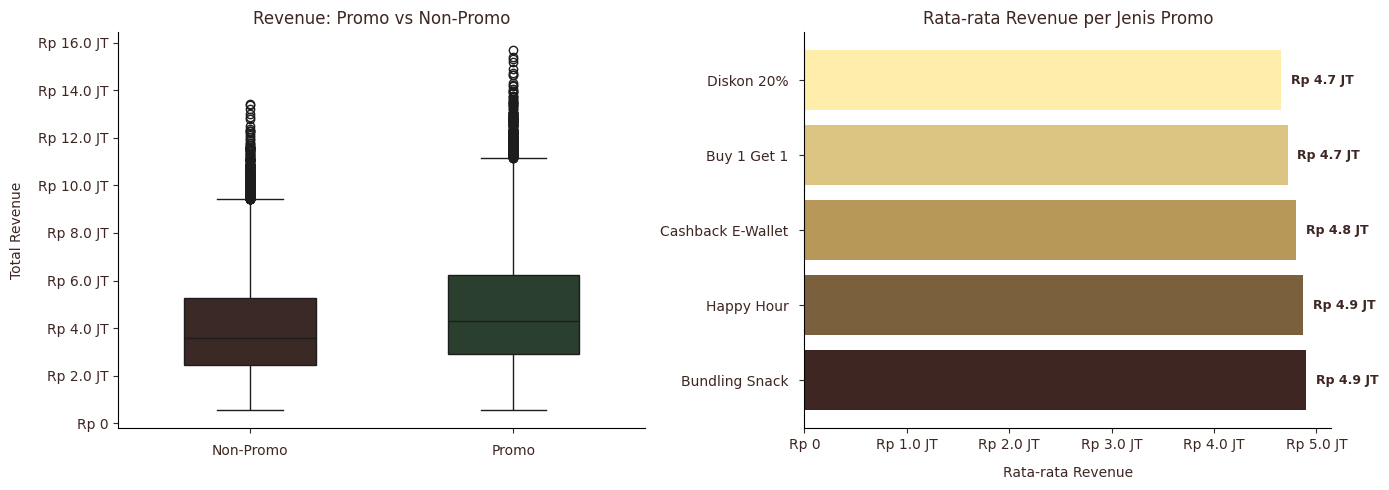


💡 INSIGHT: Promo meningkatkan revenue — tapi perlu dibandingkan vs operating cost untuk tahu apakah profit ikut naik.


In [7]:
fig, axes = buat_figure(1, 2, figsize=(14, 5))

# Plot 1: Boxplot promo vs non-promo
ax1 = axes[0]
sns.boxplot(x='promo_active', y='total_revenue', data=df,
            palette=KOPI_DUO, width=0.5, ax=ax1,
            hue='promo_active', legend=False)
ax1.set_title('Revenue: Promo vs Non-Promo')
ax1.set_xlabel('', labelpad=10)
ax1.set_xticklabels(['Non-Promo', 'Promo'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax1.set_ylabel('Total Revenue', labelpad=10)
ax1.tick_params(axis='x', pad=8)

# Plot 2: Bar horizontal revenue per jenis promo
ax2 = axes[1]
promo_type_rev = (
    df[df['promo_active'] == True]
    .groupby('promo_type')['total_revenue']
    .mean()
    .sort_values(ascending=False)
)
bars = ax2.barh(promo_type_rev.index, promo_type_rev.values,
                color=kopi_colors(len(promo_type_rev), reverse=True))
ax2.set_title('Rata-rata Revenue per Jenis Promo')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax2.set_xlabel('Rata-rata Revenue', labelpad=10)
ax2.tick_params(axis='y', pad=8)
for bar in bars:
    ax2.text(bar.get_width() + bar.get_width() * 0.02,
             bar.get_y() + bar.get_height() / 2,
             fmt_rupiah(bar.get_width()),
             va='center', ha='left', fontsize=9,
             fontweight='bold', color=KOPI_DARK)

plt.tight_layout()
plt.show()
print('\n💡 INSIGHT: Promo meningkatkan revenue — tapi perlu dibandingkan vs operating cost untuk tahu apakah profit ikut naik.')


C:\Users\HP\AppData\Local\Temp\ipykernel_19960\2613486412.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Non-Promo', 'Promo'], color='white')  # warna coklat tua


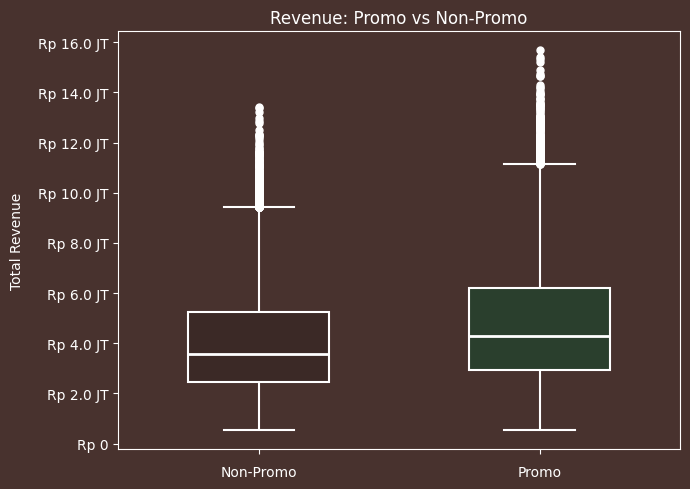

In [62]:
fig, ax1 = plt.subplots(figsize=(7, 5))

fig.patch.set_facecolor('#48322E')   # background figure
ax1.set_facecolor('#48322E') # background axes

# Warna garis boxplot
box_style = dict(color='white', linewidth=1.5)

sns.boxplot(x='promo_active', y='total_revenue', data=df,
            palette=KOPI_DUO, width=0.5, ax=ax1,
            hue='promo_active', legend=False,
            boxprops=dict(edgecolor='white', linewidth=1.5),      # ← edgecolor
            whiskerprops=dict(color='white', linewidth=1.5),
            capprops=dict(color='white', linewidth=1.5),
            medianprops=dict(color='white', linewidth=2),
            flierprops=dict(markerfacecolor='white',
                            markeredgecolor='white',
                            marker='o', markersize=5))

ax1.set_title('Revenue: Promo vs Non-Promo', color='white')  # warna coklat tua
ax1.set_xlabel('', labelpad=10)
ax1.set_xticklabels(['Non-Promo', 'Promo'], color='white')  # warna coklat tua
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax1.set_ylabel('Total Revenue', labelpad=10, color='white')
ax1.tick_params(axis='x', pad=8, colors='white')
ax1.tick_params(axis='y', colors='white')

for spine in ax1.spines.values():
    spine.set_color('white')  # warna coklat tua

plt.tight_layout()
plt.show()

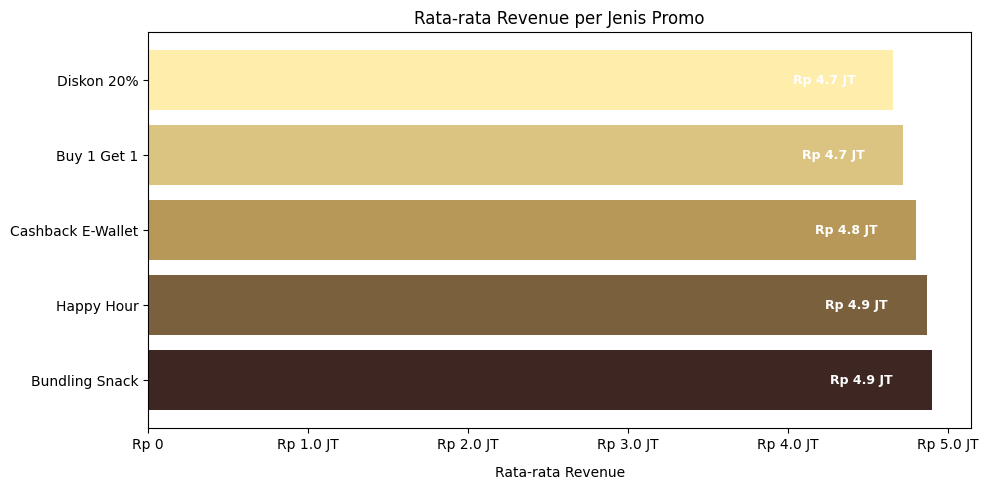

In [9]:
fig, ax2 = plt.subplots(figsize=(10, 5))

promo_type_rev = (
    df[df['promo_active'] == True]
    .groupby('promo_type')['total_revenue']
    .mean()
    .sort_values(ascending=False)
)

bars = ax2.barh(promo_type_rev.index, promo_type_rev.values,
                color=kopi_colors(len(promo_type_rev), reverse=True))

ax2.set_title('Rata-rata Revenue per Jenis Promo')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax2.set_xlabel('Rata-rata Revenue', labelpad=10)

for bar in bars:
    width = bar.get_width()
    ax2.text(width - width * 0.05,
             bar.get_y() + bar.get_height() / 2,
             fmt_rupiah(width),
             va='center', ha='right',
             fontsize=9,
             fontweight='bold',
             color='white')

plt.tight_layout()
plt.show()

In [10]:
# Cek: apakah promo juga meningkatkan PROFIT?
promo_profit = df.groupby('promo_active')[['total_revenue','operating_cost','profit','profit_margin']].mean()
promo_profit.index = ['Non-Promo', 'Promo']
print('Rata-rata komponen finansial:')
print(promo_profit.to_string(float_format='{:,.0f}'.format))


Rata-rata komponen finansial:
           total_revenue  operating_cost    profit  profit_margin
Non-Promo      4,014,043       2,930,330 1,083,713              7
Promo          4,790,274       2,955,866 1,834,408             22


Insight: Promo juga meningkatkan profit

---
## Analisis 2: Cabang Mana yang Menunjukkan Performa Paling Optimal dari Sisi Profitabilitas?

In [11]:
# Profit per kota
city_profit = (
    df.groupby('branch_city')
    .agg(total_revenue=('total_revenue','sum'),
         total_cost=('operating_cost','sum'),
         total_profit=('profit','sum'))
    .assign(profit_margin=lambda x: (x['total_profit']/x['total_revenue'])*100)
    .sort_values('profit_margin', ascending=False)
)
print(city_profit.to_string(float_format='{:,.0f}'.format))


             total_revenue     total_cost   total_profit  profit_margin
branch_city                                                            
Jakarta     48,599,463,000 31,221,154,500 17,378,308,500             36
Surabaya    16,491,497,000 11,056,330,000  5,435,167,000             33
Malang       2,742,039,000  1,885,476,500    856,562,500             31
Makassar     3,270,630,000  2,284,733,000    985,897,000             30
Medan        6,766,572,000  4,762,224,500  2,004,347,500             30
Bandung     19,595,181,000 13,852,939,500  5,742,241,500             29
Denpasar     5,260,736,000  3,863,650,000  1,397,086,000             27
Yogyakarta  11,269,443,000  8,327,443,500  2,941,999,500             26
Semarang     6,069,001,000  4,946,917,500  1,122,083,500             18


In [12]:
# Profit per branch_type
type_profit = (
    df.groupby('branch_type')
    .agg(avg_revenue=('total_revenue','mean'),
         avg_cost=('operating_cost','mean'),
         avg_profit=('profit','mean'),
         avg_margin=('profit_margin','mean'))
    .sort_values('avg_profit', ascending=False)
)
print(type_profit.to_string(float_format='{:,.0f}'.format))


             avg_revenue  avg_cost  avg_profit  avg_margin
branch_type                                               
Mall           5,837,297 3,437,176   2,400,121          35
Office Area    5,751,419 3,697,640   2,053,779          12
Stand Alone    3,326,002 2,466,599     859,403          19
University     2,254,040 2,352,221     -98,180         -38


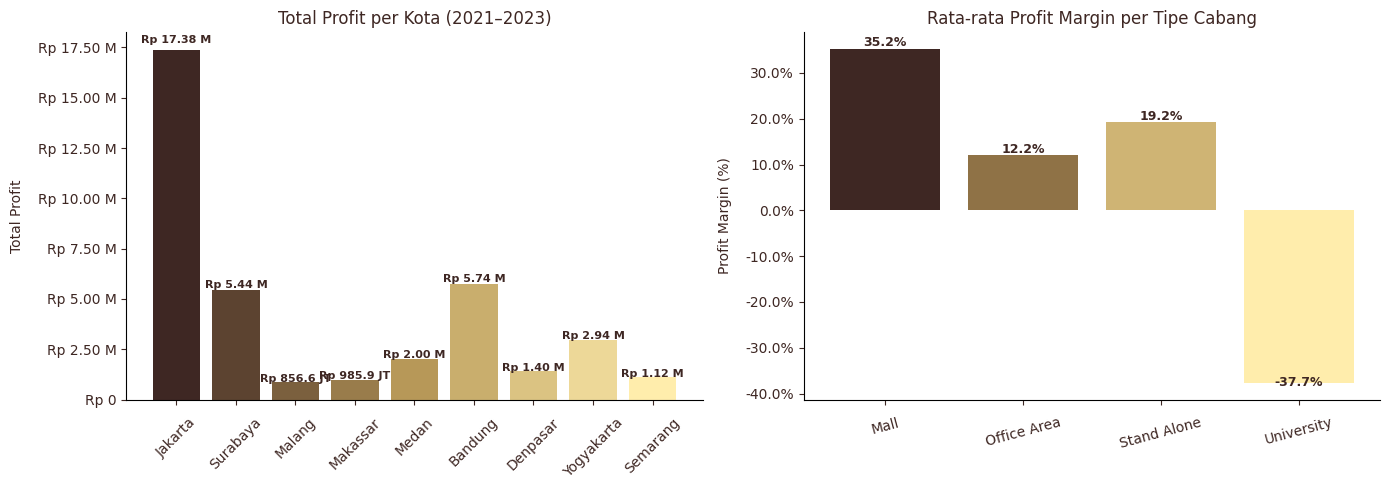


💡 INSIGHT: Perhatikan kota + tipe cabang yang memberikan margin tertinggi sebagai kandidat ekspansi.


In [13]:
fig, axes = buat_figure(1, 2, figsize=(14, 5))

# Plot 1: Total profit per kota
ax1 = axes[0]
bars = ax1.bar(city_profit.index, city_profit['total_profit'],
               color=kopi_colors(len(city_profit), reverse=True))
ax1.set_title('Total Profit per Kota (2021–2023)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax1.set_ylabel('Total Profit', labelpad=10)
ax1.tick_params(axis='x', rotation=45, pad=8)
for bar in bars:
    v = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, v + v * 0.02,
             fmt_rupiah(v), ha='center', fontsize=8,
             fontweight='bold', color=KOPI_DARK)

# Plot 2: Profit margin per tipe cabang
ax2 = axes[1]
bars2 = ax2.bar(type_profit.index, type_profit['avg_margin'],
                color=kopi_colors(len(type_profit), reverse=True))
ax2.set_title('Rata-rata Profit Margin per Tipe Cabang')
ax2.set_ylabel('Profit Margin (%)', labelpad=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax2.tick_params(axis='x', rotation=15, pad=8)
for bar in bars2:
    v = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, v + v * 0.02,
             f'{v:.1f}%', ha='center', fontsize=9,
             fontweight='bold', color=KOPI_DARK)

plt.tight_layout()
plt.show()
print('\n💡 INSIGHT: Perhatikan kota + tipe cabang yang memberikan margin tertinggi sebagai kandidat ekspansi.')


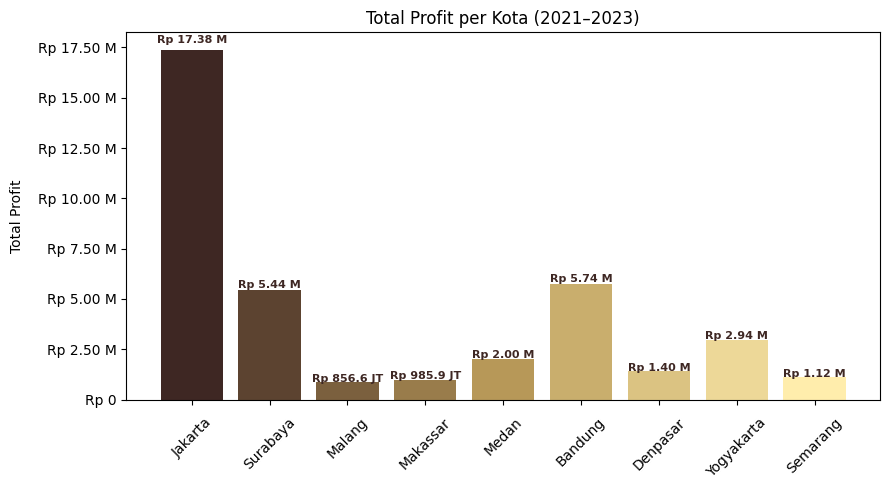

In [14]:
fig, ax1 = plt.subplots(figsize=(9, 5))

bars = ax1.bar(city_profit.index, city_profit['total_profit'],
               color=kopi_colors(len(city_profit), reverse=True))

ax1.set_title('Total Profit per Kota (2021–2023)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax1.set_ylabel('Total Profit', labelpad=10)
ax1.tick_params(axis='x', rotation=45, pad=8)

for bar in bars:
    v = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, v + v * 0.02,
             fmt_rupiah(v), ha='center', fontsize=8,
             fontweight='bold', color=KOPI_DARK)

plt.tight_layout()
plt.show()

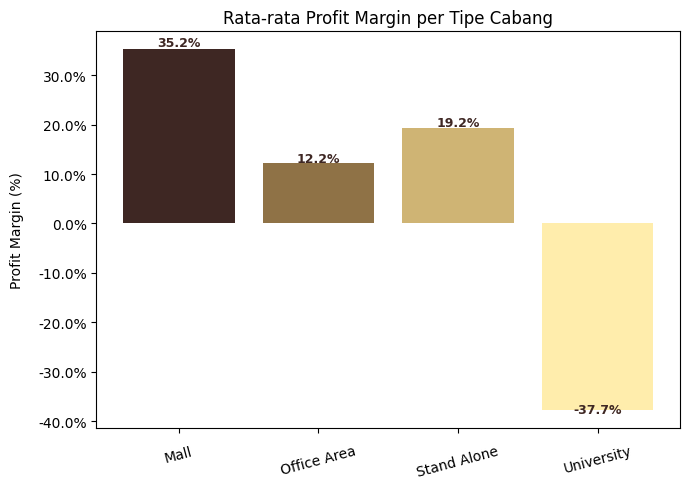

In [15]:
fig, ax2 = plt.subplots(figsize=(7, 5))

bars2 = ax2.bar(type_profit.index, type_profit['avg_margin'],
                color=kopi_colors(len(type_profit), reverse=True))

ax2.set_title('Rata-rata Profit Margin per Tipe Cabang')
ax2.set_ylabel('Profit Margin (%)', labelpad=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax2.tick_params(axis='x', rotation=15, pad=8)

for bar in bars2:
    v = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, v + v * 0.02,
             f'{v:.1f}%', ha='center', fontsize=9,
             fontweight='bold', color=KOPI_DARK)

plt.tight_layout()
plt.show()

### 📍 Wilayah Kandidat Ekspansi Selanjutnya

In [16]:
# ── Skor Ekspansi: profitabilitas tinggi + saturasi rendah = peluang besar ──
ekspansi = (
    df.groupby(['branch_city', 'branch_province'])
    .agg(
        jumlah_cabang   = ('branch_id',       'nunique'),
        avg_profit_margin = ('profit_margin',  'mean'),
        avg_revenue     = ('total_revenue',    'mean'),
        avg_profit      = ('profit',           'mean')
    )
    .round(2)
    .reset_index()
)

# Normalisasi: margin tinggi (60%) + sedikit cabang (40%) → skor peluang ekspansi
m_max = ekspansi['avg_profit_margin'].max()
c_max = ekspansi['jumlah_cabang'].max()
ekspansi['skor_ekspansi'] = (
    (ekspansi['avg_profit_margin'] / m_max * 0.6) +
    ((1 - ekspansi['jumlah_cabang'] / c_max) * 0.4)
).round(3)

ekspansi = ekspansi.sort_values('skor_ekspansi', ascending=False).reset_index(drop=True)
print('Ranking kota berdasarkan potensi ekspansi:')
print(ekspansi[['branch_city','branch_province','jumlah_cabang',
                'avg_profit_margin','avg_revenue','skor_ekspansi']].to_string(index=False))


Ranking kota berdasarkan potensi ekspansi:
branch_city  branch_province  jumlah_cabang  avg_profit_margin  avg_revenue  skor_ekspansi
   Makassar Sulawesi Selatan              2              21.15   4177049.81          0.933
   Denpasar             Bali              3              14.10   3556954.70          0.700
     Malang       Jawa Timur              2              10.73   4291140.85          0.638
      Medan   Sumatera Utara              3              10.33   3931767.58          0.593
   Surabaya       Jawa Timur              5              12.10   4374402.39          0.577
    Bandung       Jawa Barat              6              11.35   4023651.13          0.522
    Jakarta      DKI Jakarta             12              17.15   5033605.70          0.487
 Yogyakarta    DI Yogyakarta              4               6.47   3670828.34          0.450
   Semarang      Jawa Tengah              3               0.33   3069803.24          0.309


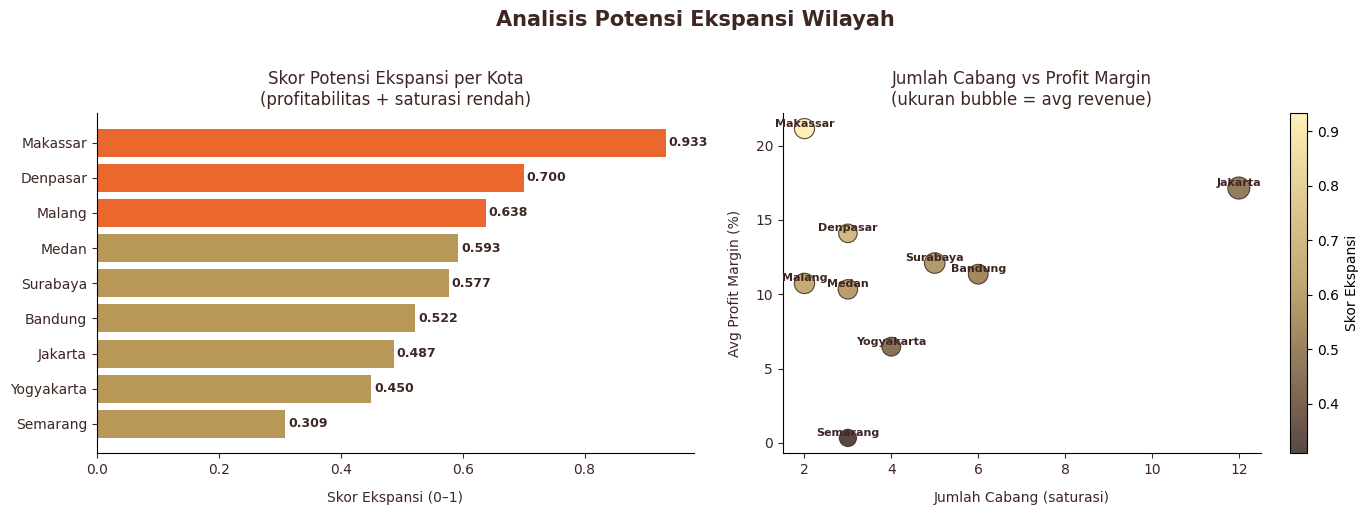


💡 REKOMENDASI EKSPANSI:
  ✅ Makassar (Sulawesi Selatan): margin tinggi (21.1%), cabang masih sedikit (2 cabang), avg revenue kuat (Rp 4.2 JT)
  ✅ Denpasar (Bali): cabang masih sedikit (3 cabang)
  ✅ Malang (Jawa Timur): cabang masih sedikit (2 cabang), avg revenue kuat (Rp 4.3 JT)


In [17]:
fig, axes = buat_figure(1, 2, figsize=(14, 5),
                         judul_besar='Analisis Potensi Ekspansi Wilayah')

# Plot 1: Skor Ekspansi per kota
ax1 = axes[0]
colors_eksp = [KOPI_ORANGE if i < 3 else KOPI_MID for i in range(len(ekspansi))]
bars = ax1.barh(ekspansi['branch_city'], ekspansi['skor_ekspansi'],
                color=colors_eksp)
ax1.set_title('Skor Potensi Ekspansi per Kota\n(profitabilitas + saturasi rendah)')
ax1.set_xlabel('Skor Ekspansi (0–1)', labelpad=10)
ax1.invert_yaxis()
for bar in bars:
    ax1.text(bar.get_width() + 0.005,
             bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.3f}',
             va='center', ha='left', fontsize=9,
             fontweight='bold', color=KOPI_DARK)

# Plot 2: Bubble chart — cabang vs margin vs revenue
ax2 = axes[1]
sc = ax2.scatter(ekspansi['jumlah_cabang'], ekspansi['avg_profit_margin'],
                 s=ekspansi['avg_revenue'] / 20_000,
                 c=ekspansi['skor_ekspansi'], cmap=KOPI_CMAP_R,
                 alpha=0.85, edgecolors=KOPI_DARK, linewidths=0.8)
plt.colorbar(sc, ax=ax2, label='Skor Ekspansi')
for _, row in ekspansi.iterrows():
    ax2.annotate(row['branch_city'],
                 (row['jumlah_cabang'], row['avg_profit_margin']),
                 fontsize=8, ha='center', va='bottom',
                 color=KOPI_DARK, fontweight='bold')
ax2.set_title('Jumlah Cabang vs Profit Margin\n(ukuran bubble = avg revenue)')
ax2.set_xlabel('Jumlah Cabang (saturasi)', labelpad=10)
ax2.set_ylabel('Avg Profit Margin (%)', labelpad=10)

plt.tight_layout()
plt.show()

print("\n💡 REKOMENDASI EKSPANSI:")
top3 = ekspansi.head(3)
for _, row in top3.iterrows():
    alasan = []
    if row['avg_profit_margin'] > 15:
        alasan.append(f"margin tinggi ({row['avg_profit_margin']:.1f}%)")
    if row['jumlah_cabang'] <= 3:
        alasan.append(f"cabang masih sedikit ({int(row['jumlah_cabang'])} cabang)")
    if row['avg_revenue'] > 4_000_000:
        alasan.append(f"avg revenue kuat ({fmt_rupiah(row['avg_revenue'])})")
    print(f"  ✅ {row['branch_city']} ({row['branch_province']}): {', '.join(alasan)}")


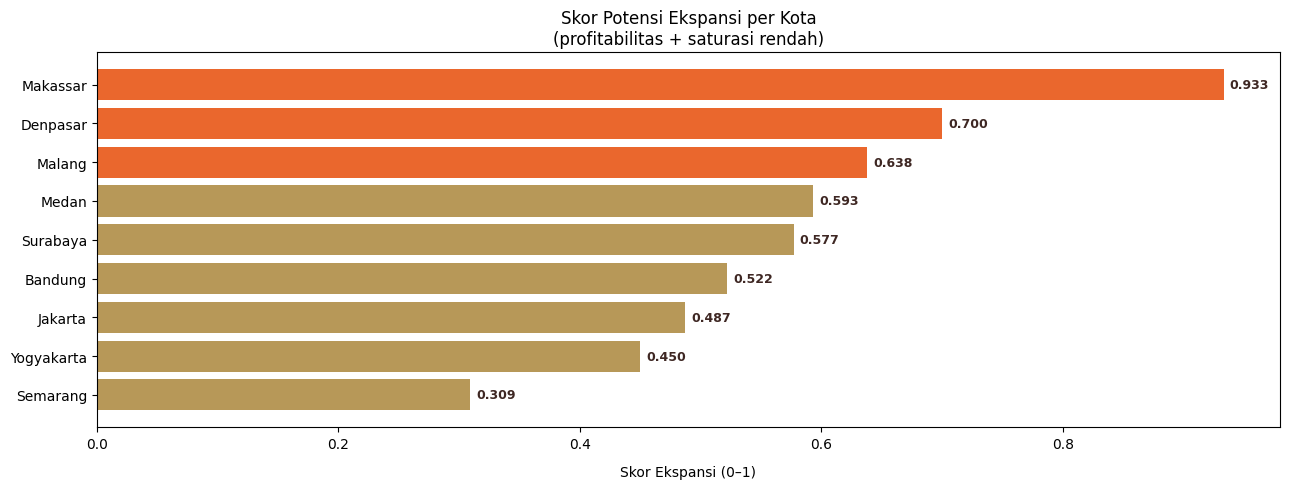

In [18]:
fig, ax1 = plt.subplots(figsize=(13, 5))

# Plot 1: Skor Ekspansi per kota
# ax1 = axes[0]
colors_eksp = [KOPI_ORANGE if i < 3 else KOPI_MID for i in range(len(ekspansi))]
bars = ax1.barh(ekspansi['branch_city'], ekspansi['skor_ekspansi'],
                color=colors_eksp)
ax1.set_title('Skor Potensi Ekspansi per Kota\n(profitabilitas + saturasi rendah)')
ax1.set_xlabel('Skor Ekspansi (0–1)', labelpad=10)
ax1.invert_yaxis()
for bar in bars:
    ax1.text(bar.get_width() + 0.005,
             bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.3f}',
             va='center', ha='left', fontsize=9,
             fontweight='bold', color=KOPI_DARK)

plt.tight_layout()
plt.show()

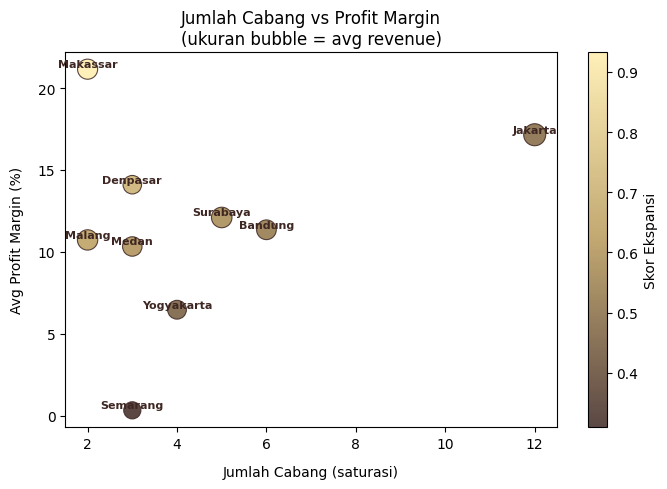

In [19]:
fig, ax2 = plt.subplots(figsize=(7, 5))

# Plot 2: Bubble chart — cabang vs margin vs revenue
# ax2 = axes[1]
sc = ax2.scatter(ekspansi['jumlah_cabang'], ekspansi['avg_profit_margin'],
                 s=ekspansi['avg_revenue'] / 20_000,
                 c=ekspansi['skor_ekspansi'], cmap=KOPI_CMAP_R,
                 alpha=0.85, edgecolors=KOPI_DARK, linewidths=0.8)
plt.colorbar(sc, ax=ax2, label='Skor Ekspansi')
for _, row in ekspansi.iterrows():
    ax2.annotate(row['branch_city'],
                 (row['jumlah_cabang'], row['avg_profit_margin']),
                 fontsize=8, ha='center', va='bottom',
                 color=KOPI_DARK, fontweight='bold')
ax2.set_title('Jumlah Cabang vs Profit Margin\n(ukuran bubble = avg revenue)')
ax2.set_xlabel('Jumlah Cabang (saturasi)', labelpad=10)
ax2.set_ylabel('Avg Profit Margin (%)', labelpad=10)

plt.tight_layout()
plt.show()

---
## Analisis 3: Apakah Peningkatan Jumlah Transaksi Selalu Menghasilkan Peningkatan Revenue?

In [20]:
# Korelasi
corr_cols = ['total_transactions','total_revenue','avg_ticket_size','total_cups_sold','profit']
corr_matrix = df[corr_cols].corr()
print('Matriks korelasi:')
print(corr_matrix.round(3))

r, p = stats.pearsonr(df['total_transactions'], df['total_revenue'])
print(f'\nKorelasi transaksi vs revenue: r={r:.3f}, p={p:.4e}')


Matriks korelasi:
                    total_transactions  total_revenue  avg_ticket_size  \
total_transactions               1.000          0.831            0.447   
total_revenue                    0.831          1.000            0.738   
avg_ticket_size                  0.447          0.738            1.000   
total_cups_sold                  0.861          0.889            0.457   
profit                           0.833          0.976            0.649   

                    total_cups_sold  profit  
total_transactions            0.861   0.833  
total_revenue                 0.889   0.976  
avg_ticket_size               0.457   0.649  
total_cups_sold               1.000   0.897  
profit                        0.897   1.000  

Korelasi transaksi vs revenue: r=0.831, p=0.0000e+00


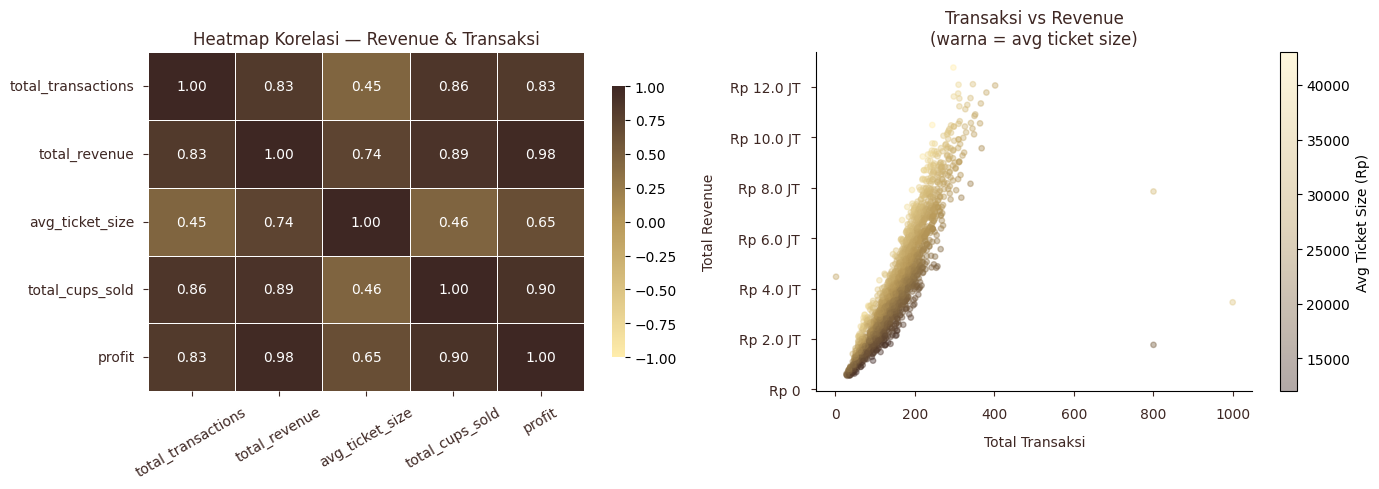


💡 INSIGHT: Banyak transaksi tidak selalu = revenue besar. Avg ticket size berperan penting.


In [21]:
fig, axes = buat_figure(1, 2, figsize=(14, 5))

# Plot 1: Heatmap korelasi
ax1 = axes[0]
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap=KOPI_CMAP,
            vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            ax=ax1)

ax1.set_title('Heatmap Korelasi — Revenue & Transaksi')
ax1.tick_params(axis='x', rotation=30, pad=6)
ax1.tick_params(axis='y', rotation=0,  pad=6)

# Plot 2: Scatter transaksi vs revenue, gradasi = avg ticket size
ax2 = axes[1]
sample = df.sample(min(2000, len(df)), random_state=42)
sc = ax2.scatter(sample['total_transactions'], sample['total_revenue'],
                 c=sample['avg_ticket_size'],
                 cmap=KOPI_CMAP_R,
                 alpha=0.4, s=15)
plt.colorbar(sc, ax=ax2, label='Avg Ticket Size (Rp)')
ax2.set_title('Transaksi vs Revenue\n(warna = avg ticket size)')
ax2.set_xlabel('Total Transaksi', labelpad=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax2.set_ylabel('Total Revenue', labelpad=10)
ax2.tick_params(axis='x', pad=8)
ax2.tick_params(axis='y', pad=8)

plt.tight_layout()
plt.show()
print('\n💡 INSIGHT: Banyak transaksi tidak selalu = revenue besar. Avg ticket size berperan penting.')


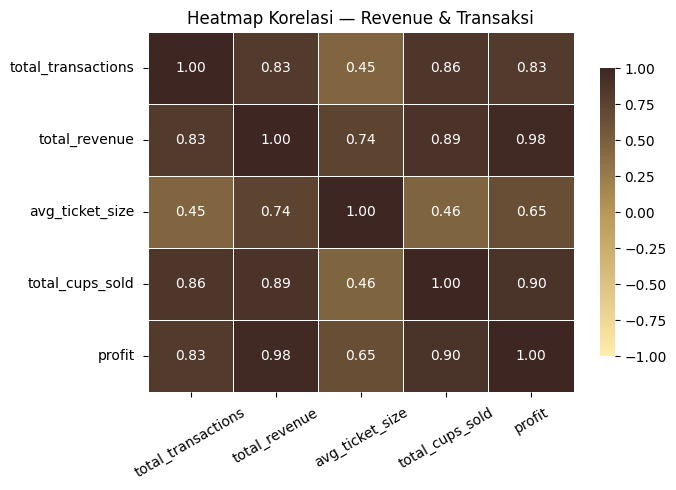

In [22]:
# Plot 1: Heatmap korelasi
fig, ax1 = plt.subplots(figsize=(7, 5))

sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap=KOPI_CMAP,
            vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            ax=ax1)

ax1.set_title('Heatmap Korelasi — Revenue & Transaksi')
ax1.tick_params(axis='x', rotation=30, pad=6)
ax1.tick_params(axis='y', rotation=0,  pad=6)

plt.tight_layout()
plt.show()

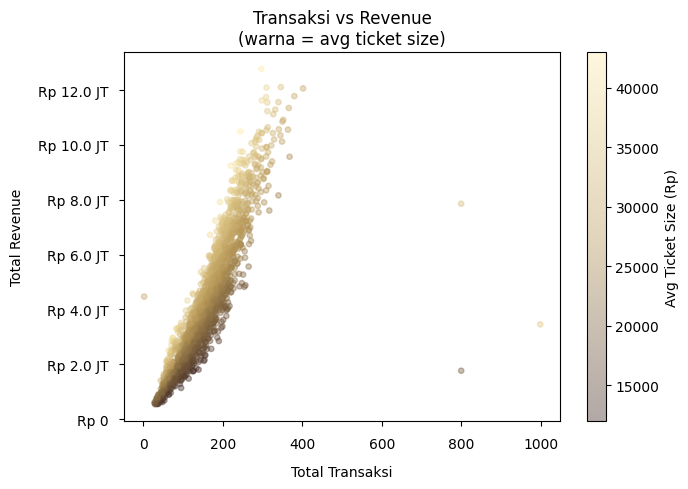

In [23]:
fig, ax2 = plt.subplots(figsize=(7, 5))

# Plot 2: Scatter transaksi vs revenue, gradasi = avg ticket size
# ax2 = axes[1]
sample = df.sample(min(2000, len(df)), random_state=42)
sc = ax2.scatter(sample['total_transactions'], sample['total_revenue'],
                 c=sample['avg_ticket_size'],
                 cmap=KOPI_CMAP_R,
                 alpha=0.4, s=15)
plt.colorbar(sc, ax=ax2, label='Avg Ticket Size (Rp)')
ax2.set_title('Transaksi vs Revenue\n(warna = avg ticket size)')
ax2.set_xlabel('Total Transaksi', labelpad=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax2.set_ylabel('Total Revenue', labelpad=10)
ax2.tick_params(axis='x', pad=8)
ax2.tick_params(axis='y', pad=8)

plt.tight_layout()
plt.show()

---
## Analisis 4: Apakah Faktor Waktu Operasional (Weekday vs Weekend) Mempengaruhi Performa Penjualan?
> ⚠️ **Perbaikan label:** sebelumnya salah diberi label *Analisis 5* — sekarang diperbaiki menjadi *Analisis 4* sesuai urutan pertanyaan bisnis.

In [24]:
weekend_summary = (
    df.groupby('is_weekend')
    .agg(
        avg_transactions=('total_transactions','mean'),
        avg_revenue     =('total_revenue',     'mean'),
        avg_profit      =('profit',            'mean'),
        avg_satisfaction=('customer_satisfaction','mean'),
        count           =('date',              'count')
    )
)
weekend_summary.index = ['Weekday','Weekend']
print(weekend_summary.round(2))

# Uji signifikansi revenue (Welch t-test)
t, p = stats.ttest_ind(
    df[df['is_weekend']==True]['total_revenue'],
    df[df['is_weekend']==False]['total_revenue'],
    equal_var=False
)
print(f'\nt-test revenue: t={t:.2f}, p={p:.4f}')
print('→ Signifikan secara statistik (p < 0.05)' if p < 0.05 else '→ Tidak signifikan')


         avg_transactions  avg_revenue  avg_profit  avg_satisfaction  count
Weekday            161.12   4332791.46  1431091.28              3.85  20020
Weekend            154.91   4194621.98  1159774.11              3.82   7944

t-test revenue: t=-4.02, p=0.0001
→ Signifikan secara statistik (p < 0.05)


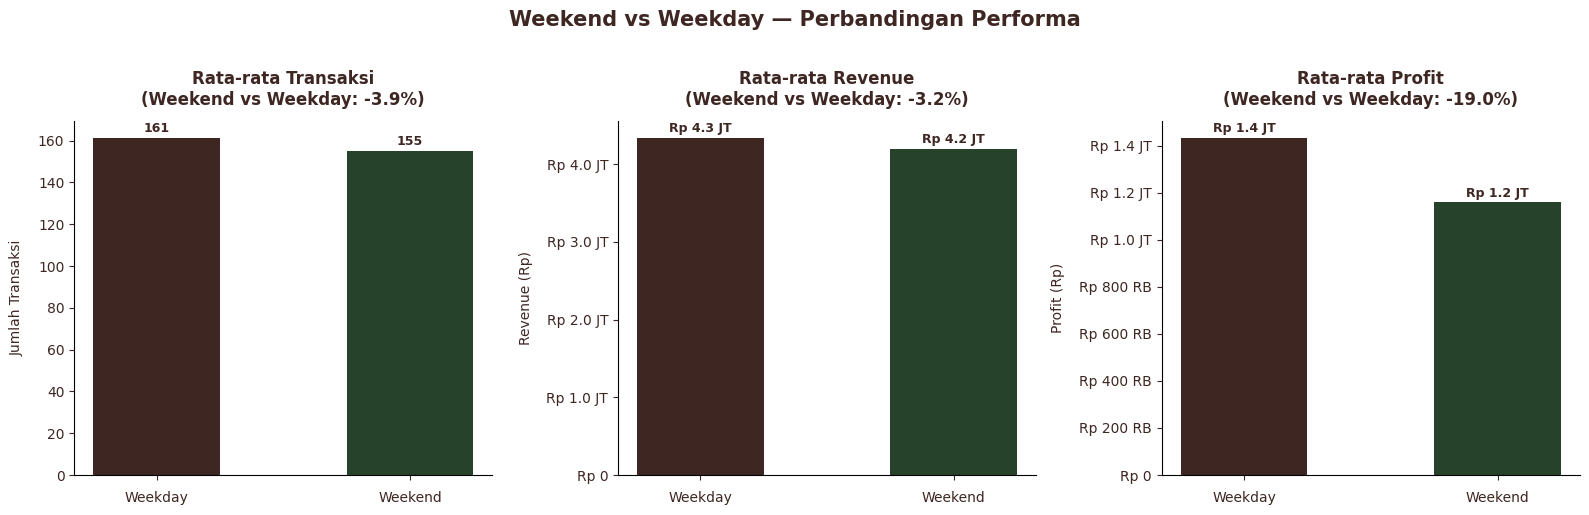


💡 INSIGHT: Weekend effect perlu diukur dari revenue DAN profit — bukan sekadar transaksi.


In [25]:
fig, axes = buat_figure(1, 3, figsize=(16, 5),
                         judul_besar='Weekend vs Weekday — Perbandingan Performa')
labels = ['Weekday', 'Weekend']
colors = KOPI_DUO

metrics = [
    ('avg_transactions', 'Rata-rata Transaksi',  'Jumlah Transaksi', None),
    ('avg_revenue',      'Rata-rata Revenue',     'Revenue (Rp)',     fmt_rupiah),
    ('avg_profit',       'Rata-rata Profit',      'Profit (Rp)',      fmt_rupiah),
]

for ax, (col, title, ylabel, formatter) in zip(axes, metrics):
    values   = weekend_summary[col].values
    bars     = ax.bar(labels, values, color=colors, width=0.5)
    # values[0]=Weekday (is_weekend=False), values[1]=Weekend (is_weekend=True)
    pct_diff = (values[1] - values[0]) / values[0] * 100
    ax.set_title(f'{title}\n(Weekend vs Weekday: {pct_diff:+.1f}%)',
                 fontsize=12, fontweight='bold', color=KOPI_DARK, pad=12)
    ax.set_ylabel(ylabel, labelpad=10)
    ax.tick_params(axis='x', pad=8)
    if formatter:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
    for bar, v in zip(bars, values):
        label_txt = formatter(v) if formatter else f'{v:.0f}'
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + v * 0.02, label_txt,
                ha='center', fontsize=9,
                fontweight='bold', color=KOPI_DARK)

plt.tight_layout()
plt.show()
print('\n💡 INSIGHT: Weekend effect perlu diukur dari revenue DAN profit — bukan sekadar transaksi.')


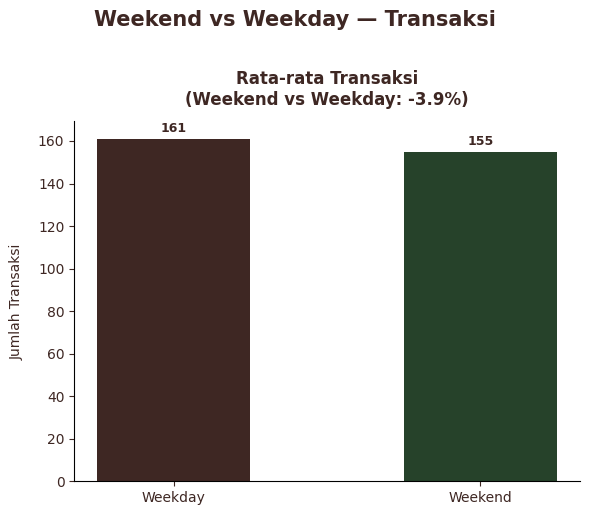

In [26]:
fig, ax = buat_figure(1, 1, figsize=(6, 5),
                      judul_besar='Weekend vs Weekday — Transaksi')

labels = ['Weekday', 'Weekend']
values = weekend_summary['avg_transactions'].values

bars = ax.bar(labels, values, color=KOPI_DUO, width=0.5)

pct_diff = (values[1] - values[0]) / values[0] * 100

ax.set_title(f'Rata-rata Transaksi\n(Weekend vs Weekday: {pct_diff:+.1f}%)',
             fontsize=12, fontweight='bold', color=KOPI_DARK, pad=12)
ax.set_ylabel('Jumlah Transaksi', labelpad=10)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + v * 0.02,
            f'{v:.0f}',
            ha='center', fontsize=9,
            fontweight='bold', color=KOPI_DARK)

plt.tight_layout()
plt.show()

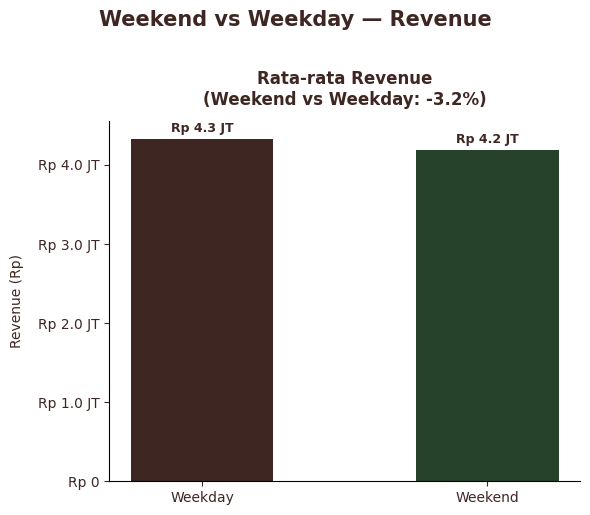

In [27]:
fig, ax = buat_figure(1, 1, figsize=(6, 5),
                      judul_besar='Weekend vs Weekday — Revenue')

labels = ['Weekday', 'Weekend']
values = weekend_summary['avg_revenue'].values

bars = ax.bar(labels, values, color=KOPI_DUO, width=0.5)

pct_diff = (values[1] - values[0]) / values[0] * 100

ax.set_title(f'Rata-rata Revenue\n(Weekend vs Weekday: {pct_diff:+.1f}%)',
             fontsize=12, fontweight='bold', color=KOPI_DARK, pad=12)
ax.set_ylabel('Revenue (Rp)', labelpad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + v * 0.02,
            fmt_rupiah(v),
            ha='center', fontsize=9,
            fontweight='bold', color=KOPI_DARK)

plt.tight_layout()
plt.show()

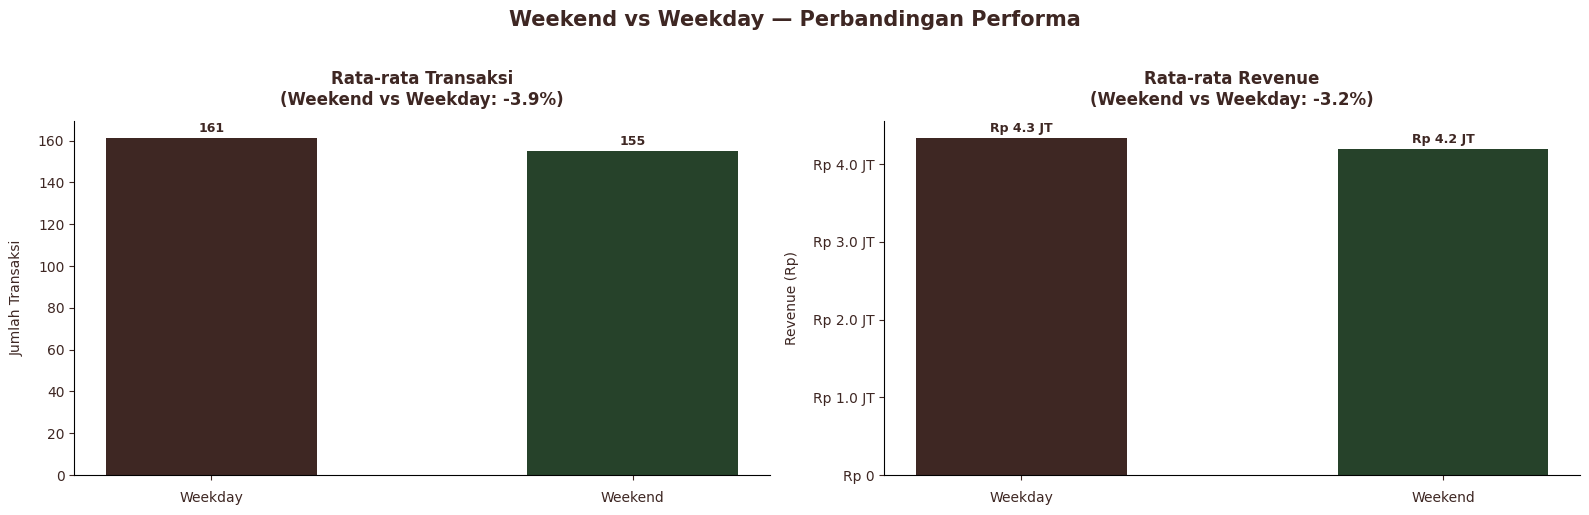


💡 INSIGHT: Weekend effect perlu diukur dari revenue DAN profit — bukan sekadar transaksi.


In [28]:
fig, axes = buat_figure(1, 2, figsize=(16, 5),
                         judul_besar='Weekend vs Weekday — Perbandingan Performa')
labels = ['Weekday', 'Weekend']
colors = KOPI_DUO

metrics = [
    ('avg_transactions', 'Rata-rata Transaksi',  'Jumlah Transaksi', None),
    ('avg_revenue',      'Rata-rata Revenue',     'Revenue (Rp)',     fmt_rupiah),
]

for ax, (col, title, ylabel, formatter) in zip(axes, metrics):
    values   = weekend_summary[col].values
    bars     = ax.bar(labels, values, color=colors, width=0.5)
    # values[0]=Weekday (is_weekend=False), values[1]=Weekend (is_weekend=True)
    pct_diff = (values[1] - values[0]) / values[0] * 100
    ax.set_title(f'{title}\n(Weekend vs Weekday: {pct_diff:+.1f}%)',
                 fontsize=12, fontweight='bold', color=KOPI_DARK, pad=12)
    ax.set_ylabel(ylabel, labelpad=10)
    ax.tick_params(axis='x', pad=8)
    if formatter:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
    for bar, v in zip(bars, values):
        label_txt = formatter(v) if formatter else f'{v:.0f}'
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + v * 0.02, label_txt,
                ha='center', fontsize=9,
                fontweight='bold', color=KOPI_DARK)

plt.tight_layout()
plt.show()
print('\n💡 INSIGHT: Weekend effect perlu diukur dari revenue DAN profit — bukan sekadar transaksi.')


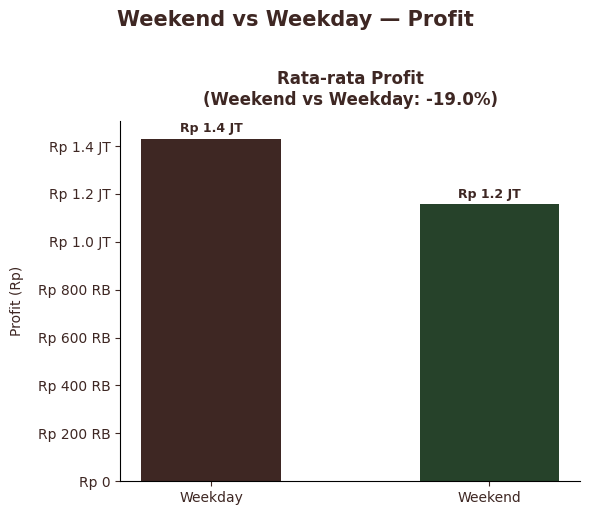

In [29]:
fig, ax = buat_figure(1, 1, figsize=(6, 5),
                      judul_besar='Weekend vs Weekday — Profit')

labels = ['Weekday', 'Weekend']
values = weekend_summary['avg_profit'].values

bars = ax.bar(labels, values, color=KOPI_DUO, width=0.5)

pct_diff = (values[1] - values[0]) / values[0] * 100

ax.set_title(f'Rata-rata Profit\n(Weekend vs Weekday: {pct_diff:+.1f}%)',
             fontsize=12, fontweight='bold', color=KOPI_DARK, pad=12)
ax.set_ylabel('Profit (Rp)', labelpad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + v * 0.02,
            fmt_rupiah(v),
            ha='center', fontsize=9,
            fontweight='bold', color=KOPI_DARK)

plt.tight_layout()
plt.show()

In [30]:
# Weekend effect per branch_type
weekend_by_type = (
    df.groupby(['branch_type','is_weekend'])['total_revenue']
    .mean()
    .unstack()
    .rename(columns={False:'Weekday', True:'Weekend'})
)
weekend_by_type['uplift_%'] = (weekend_by_type['Weekend'] / weekend_by_type['Weekday'] - 1) * 100
print(weekend_by_type.round(0))


is_weekend     Weekday    Weekend  uplift_%
branch_type                                
Mall         5319777.0  7123170.0      34.0
Office Area  7074798.0  2464746.0     -65.0
Stand Alone  3194173.0  3652936.0      14.0
University   2680826.0  1109179.0     -59.0


---
# BAGIAN 2 — Customer Behavior

## Analisis 5: Bagaimana Preferensi Channel Transaksi Pelanggan di KopiSeru?
> ⚠️ **Perbaikan label:** sebelumnya salah diberi label *Analisis 4* — sekarang diperbaiki menjadi *Analisis 5* sesuai urutan pertanyaan bisnis.

In [31]:
channel_overall = df[['dine_in_percent','delivery_percent','takeaway_percent']].mean()
channel_overall.index = ['Dine-in','Delivery','Takeaway']
print('Rata-rata distribusi channel (%):')
print(channel_overall.round(2))


Rata-rata distribusi channel (%):
Dine-in     24.16
Delivery    26.79
Takeaway    49.05
dtype: float64


In [32]:
# Channel per branch type
channel_by_type = (
    df.groupby('branch_type')[['dine_in_percent','delivery_percent','takeaway_percent']]
    .mean()
    .rename(columns={'dine_in_percent':'Dine-in',
                     'delivery_percent':'Delivery',
                     'takeaway_percent':'Takeaway'})
)
print(channel_by_type.round(1))


             Dine-in  Delivery  Takeaway
branch_type                             
Mall            25.8      30.1      44.1
Office Area      9.4      34.5      56.0
Stand Alone     34.4      24.5      41.2
University      14.4      19.7      65.9


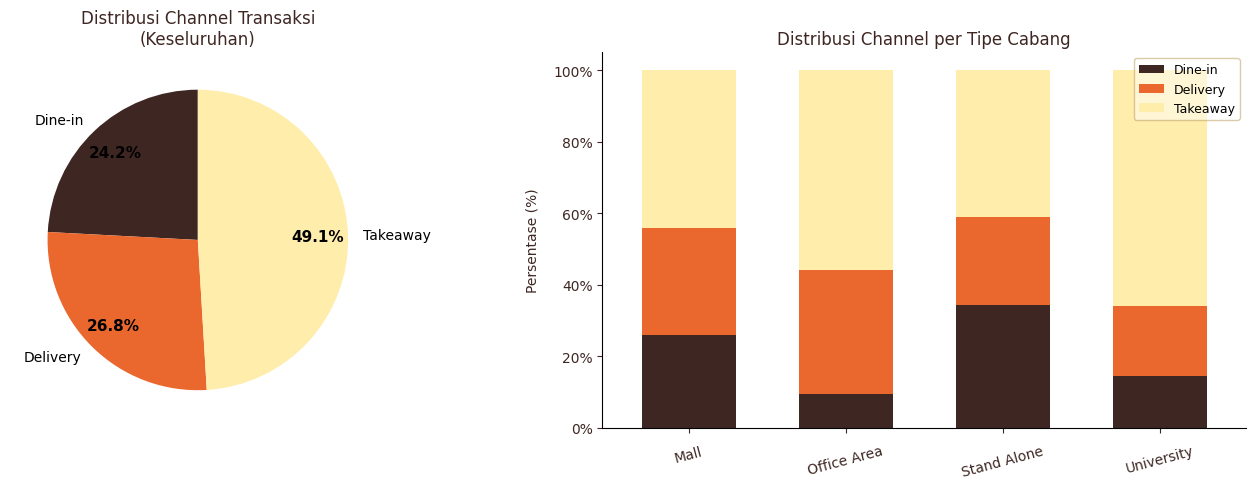


💡 INSIGHT: Temukan pola dominan per tipe cabang → implikasi pada kebutuhan space, staffing, dan kemasan.


In [33]:
fig, axes = buat_figure(1, 2, figsize=(14, 5))
colors_ch = [KOPI_DARK, KOPI_ORANGE, KOPI_LIGHT]   # 3 channel — 3 warna berbeda

# Plot 1: Pie chart overall
ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(
    channel_overall.values,
    labels=channel_overall.index,
    autopct='%1.1f%%',
    colors=colors_ch,
    startangle=90,
    pctdistance=0.8
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax1.set_title('Distribusi Channel Transaksi\n(Keseluruhan)')

# Plot 2: Stacked bar per branch type
ax2 = axes[1]
channel_by_type.plot(kind='bar', stacked=True, ax=ax2,
                     color=colors_ch, width=0.6)
ax2.set_title('Distribusi Channel per Tipe Cabang')
ax2.set_ylabel('Persentase (%)', labelpad=10)
ax2.set_xlabel('', labelpad=10)
ax2.tick_params(axis='x', rotation=15, pad=8)
ax2.legend(loc='upper right', fontsize=9,
           framealpha=0.5, edgecolor=KOPI_MID)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.show()
print('\n💡 INSIGHT: Temukan pola dominan per tipe cabang → implikasi pada kebutuhan space, staffing, dan kemasan.')


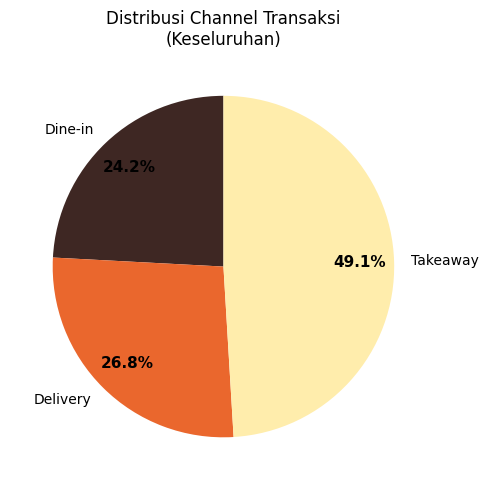

In [34]:
fig, ax1 = plt.subplots(figsize=(7, 5))
colors_ch = [KOPI_DARK, KOPI_ORANGE, KOPI_LIGHT]   # 3 channel — 3 warna berbeda

# Plot 1: Pie chart overall
# ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(
    channel_overall.values,
    labels=channel_overall.index,
    autopct='%1.1f%%',
    colors=colors_ch,
    startangle=90,
    pctdistance=0.8
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax1.set_title('Distribusi Channel Transaksi\n(Keseluruhan)')

plt.tight_layout()
plt.show()

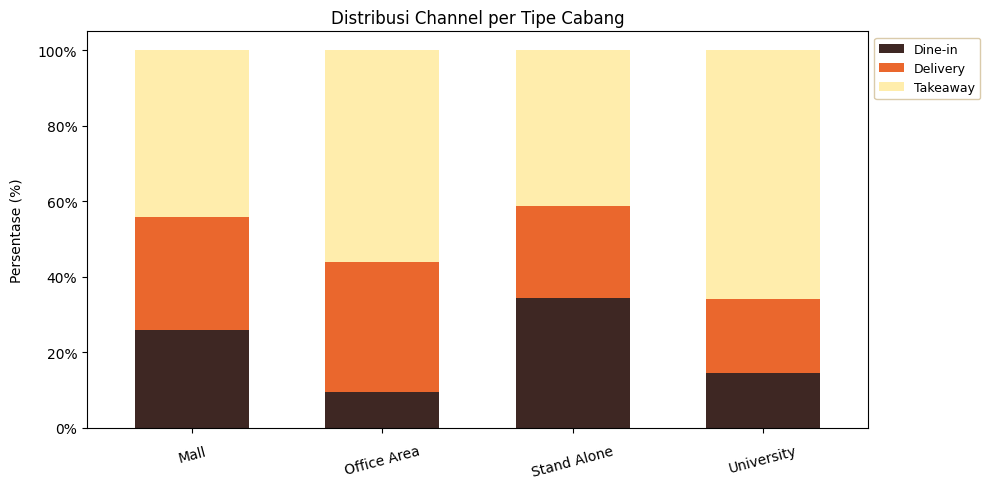

In [35]:
fig, ax2 = plt.subplots(figsize=(10, 5))
colors_ch = [KOPI_DARK, KOPI_ORANGE, KOPI_LIGHT] 

# Plot 2: Stacked bar per branch type
# ax2 = axes[1]
channel_by_type.plot(kind='bar', stacked=True, ax=ax2,
                     color=colors_ch, width=0.6)

ax2.set_title('Distribusi Channel per Tipe Cabang')
ax2.set_ylabel('Persentase (%)', labelpad=10)
ax2.set_xlabel('', labelpad=10)
ax2.tick_params(axis='x', rotation=15, pad=8)

ax2.legend(loc='upper left',
           bbox_to_anchor=(1, 1),
           fontsize=9,
           framealpha=0.5,
           edgecolor=KOPI_MID)

ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.subplots_adjust(right=0.8)
plt.tight_layout()
plt.show()

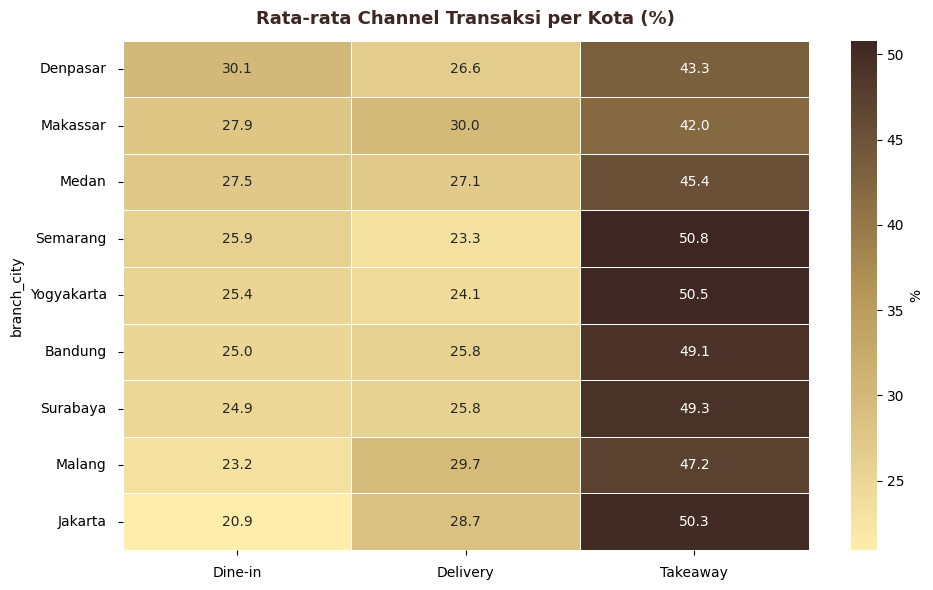

In [36]:
# Heatmap channel per kota
channel_city = (
    df.groupby('branch_city')[['dine_in_percent','delivery_percent','takeaway_percent']]
    .mean()
    .rename(columns={'dine_in_percent':'Dine-in',
                     'delivery_percent':'Delivery',
                     'takeaway_percent':'Takeaway'})
    .sort_values('Dine-in', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')
sns.heatmap(channel_city, annot=True, fmt='.1f',
            cmap=KOPI_CMAP,
            linewidths=0.5,
            cbar_kws={'label': '%'},
            ax=ax)
ax.set_title('Rata-rata Channel Transaksi per Kota (%)',
             fontsize=13, fontweight='bold', color=KOPI_DARK, pad=12)
ax.tick_params(axis='x', rotation=0, pad=8)
ax.tick_params(axis='y', rotation=0,  pad=8)
plt.tight_layout()
plt.show()


### 📲 Insight: Strategi Ekspansi Channel Selanjutnya

In [37]:
# Tren channel per tahun — apakah ada pergeseran perilaku pelanggan?
channel_trend = (
    df.groupby('year')[['dine_in_percent','delivery_percent','takeaway_percent']]
    .mean()
    .rename(columns={'dine_in_percent':'Dine-in',
                     'delivery_percent':'Delivery',
                     'takeaway_percent':'Takeaway'})
)
print('Tren channel per tahun (%):')
print(channel_trend.round(2))

# Hitung growth rate delivery (channel digital)
d_2021 = channel_trend.loc[2021, 'Delivery']
d_2023 = channel_trend.loc[2023, 'Delivery']
growth_delivery = (d_2023 - d_2021) / d_2021 * 100
print(f'\nGrowth Delivery 2021→2023: {growth_delivery:+.1f}%')


Tren channel per tahun (%):
      Dine-in  Delivery  Takeaway
year                             
2021    24.05     22.86     53.09
2022    24.42     26.16     49.42
2023    24.02     29.36     46.62

Growth Delivery 2021→2023: +28.4%


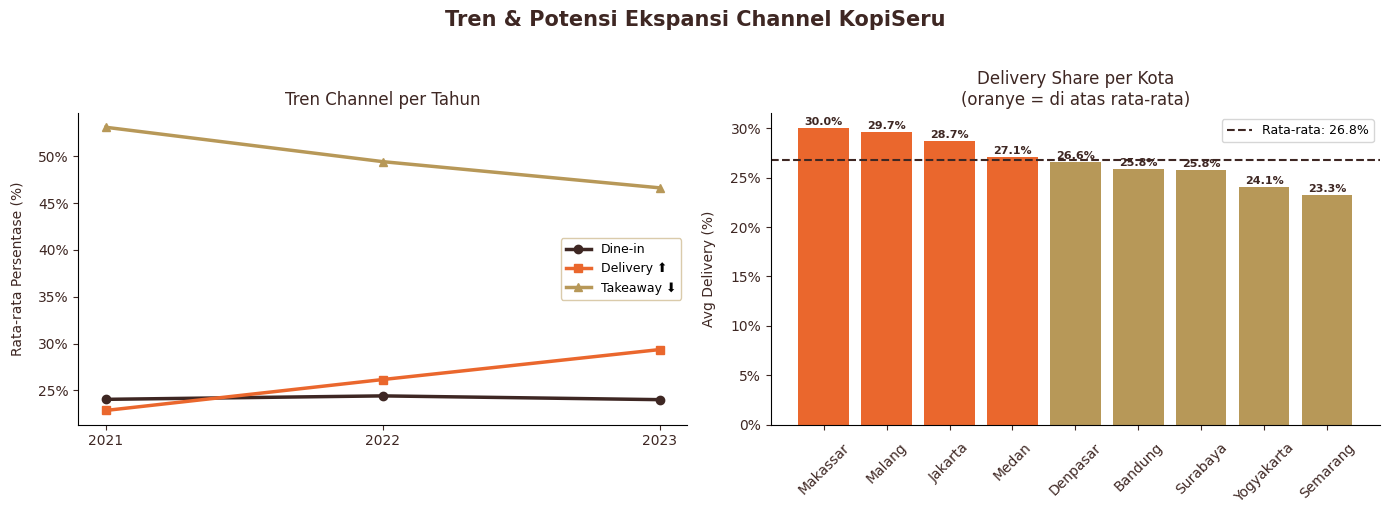


💡 REKOMENDASI EKSPANSI CHANNEL:
  📲 Delivery tumbuh konsisten (+6.5 poin 2021→2023) → prioritaskan mitra platform digital (GoFood/ShopeeFood)
  🏙️ Kota dengan delivery share rendah = peluang onboarding digital baru
  🛍️ Takeaway menurun → potensi upsell bundling/loyalty untuk channel ini


In [38]:
fig, axes = buat_figure(1, 2, figsize=(14, 5),
                         judul_besar='Tren & Potensi Ekspansi Channel KopiSeru')

# Plot 1: Line tren channel 2021–2023
ax1 = axes[0]
ax1.plot(channel_trend.index, channel_trend['Dine-in'],
         marker='o', color=KOPI_DARK,   linewidth=2.5, label='Dine-in')
ax1.plot(channel_trend.index, channel_trend['Delivery'],
         marker='s', color=KOPI_ORANGE, linewidth=2.5, label='Delivery ⬆')
ax1.plot(channel_trend.index, channel_trend['Takeaway'],
         marker='^', color=KOPI_MID,   linewidth=2.5, label='Takeaway ⬇')
ax1.set_title('Tren Channel per Tahun')
ax1.set_ylabel('Rata-rata Persentase (%)', labelpad=10)
ax1.set_xticks([2021, 2022, 2023])
ax1.legend(fontsize=9, framealpha=0.5, edgecolor=KOPI_MID)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Plot 2: Delivery share per kota (potensi pengembangan digital)
ax2 = axes[1]
delivery_city = (
    df.groupby('branch_city')['delivery_percent']
    .mean()
    .sort_values(ascending=False)
)
colors_dl = [KOPI_ORANGE if v > delivery_city.mean() else KOPI_MID
             for v in delivery_city.values]
bars = ax2.bar(delivery_city.index, delivery_city.values, color=colors_dl)
ax2.axhline(delivery_city.mean(), color=KOPI_DARK, linestyle='--',
            linewidth=1.5, label=f'Rata-rata: {delivery_city.mean():.1f}%')
ax2.set_title('Delivery Share per Kota\n(oranye = di atas rata-rata)')
ax2.set_ylabel('Avg Delivery (%)', labelpad=10)
ax2.tick_params(axis='x', rotation=45, pad=8)
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%',
             ha='center', fontsize=8,
             fontweight='bold', color=KOPI_DARK)

plt.tight_layout()
plt.show()

print('\n💡 REKOMENDASI EKSPANSI CHANNEL:')
print('  📲 Delivery tumbuh konsisten (+6.5 poin 2021→2023) → prioritaskan mitra platform digital (GoFood/ShopeeFood)')
print('  🏙️ Kota dengan delivery share rendah = peluang onboarding digital baru')
print('  🛍️ Takeaway menurun → potensi upsell bundling/loyalty untuk channel ini')


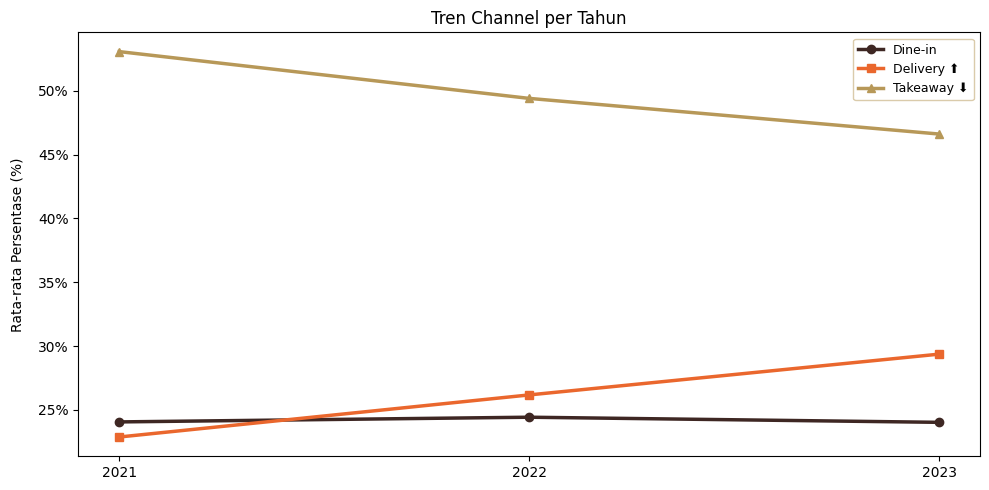

In [39]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot 1: Line tren channel 2021–2023
#ax1 = axes[0]
ax1.plot(channel_trend.index, channel_trend['Dine-in'],
         marker='o', color=KOPI_DARK,   linewidth=2.5, label='Dine-in')
ax1.plot(channel_trend.index, channel_trend['Delivery'],
         marker='s', color=KOPI_ORANGE, linewidth=2.5, label='Delivery ⬆')
ax1.plot(channel_trend.index, channel_trend['Takeaway'],
         marker='^', color=KOPI_MID,   linewidth=2.5, label='Takeaway ⬇')
ax1.set_title('Tren Channel per Tahun')
ax1.set_ylabel('Rata-rata Persentase (%)', labelpad=10)
ax1.set_xticks([2021, 2022, 2023])
ax1.legend(fontsize=9, framealpha=0.5, edgecolor=KOPI_MID)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.show()

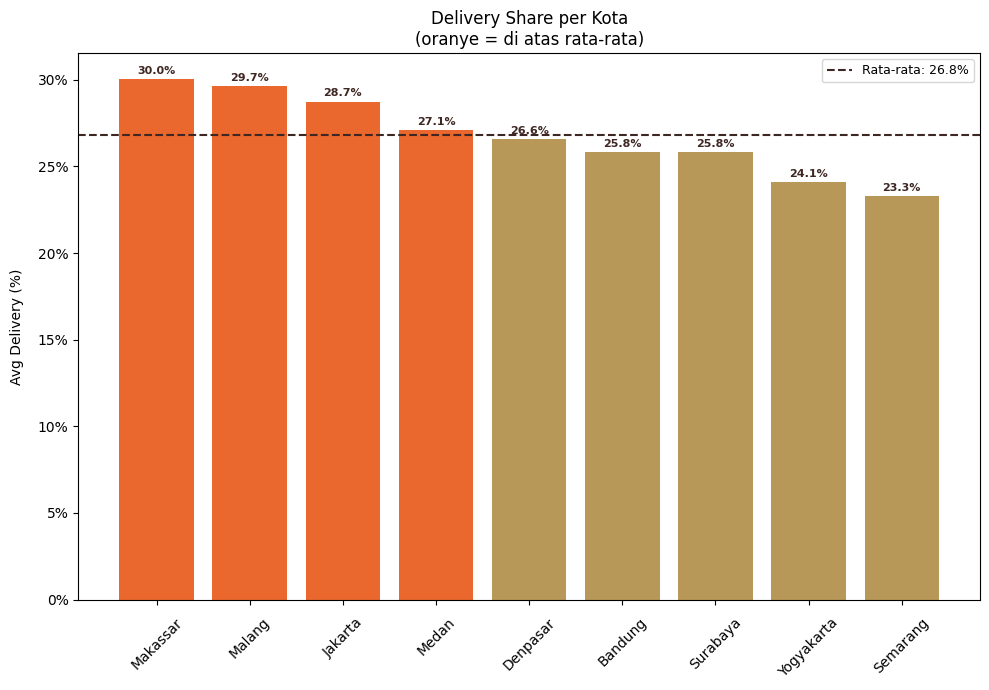

In [40]:
fig, ax2 = plt.subplots(figsize=(10, 7))

# Plot 2: Delivery share per kota (potensi pengembangan digital)
# ax2 = axes[1]
delivery_city = (
    df.groupby('branch_city')['delivery_percent']
    .mean()
    .sort_values(ascending=False)
)
colors_dl = [KOPI_ORANGE if v > delivery_city.mean() else KOPI_MID
             for v in delivery_city.values]
bars = ax2.bar(delivery_city.index, delivery_city.values, color=colors_dl)
ax2.axhline(delivery_city.mean(), color=KOPI_DARK, linestyle='--',
            linewidth=1.5, label=f'Rata-rata: {delivery_city.mean():.1f}%')
ax2.set_title('Delivery Share per Kota\n(oranye = di atas rata-rata)')
ax2.set_ylabel('Avg Delivery (%)', labelpad=10)
ax2.tick_params(axis='x', rotation=45, pad=8)
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%',
             ha='center', fontsize=8,
             fontweight='bold', color=KOPI_DARK)

plt.tight_layout()
plt.show()

---
# BAGIAN 3 — Outcome: Customer Satisfaction

## Analisis 6: Faktor Apa Saja yang Paling Mempengaruhi Customer Satisfaction di KopiSeru?

In [41]:
print('Distribusi customer satisfaction:')
print(df['customer_satisfaction'].describe().round(3))
print(f'\nSkewness: {df["customer_satisfaction"].skew():.3f}')


Distribusi customer satisfaction:
count    27964.000
mean         3.844
std          0.312
min          2.500
25%          3.600
50%          3.800
75%          4.100
max          5.000
Name: customer_satisfaction, dtype: float64

Skewness: -0.014


In [42]:
# Korelasi satisfaction vs variabel lain
sat_corr = df[['customer_satisfaction','total_revenue','total_transactions',
               'avg_ticket_size','profit_margin','employee_on_duty']].corr()['customer_satisfaction'].drop('customer_satisfaction').sort_values()
print('Korelasi dengan customer_satisfaction:')
print(sat_corr.round(3))


Korelasi dengan customer_satisfaction:
employee_on_duty     -0.033
total_transactions    0.016
profit_margin         0.028
total_revenue         0.036
avg_ticket_size       0.068
Name: customer_satisfaction, dtype: float64


#### REVISI

In [43]:
# ── REVISI: Segmentasi Customer Satisfaction ──
# Satisfaction jarang global — biasanya kontekstual per segment
print('=== Satisfaction per Tipe Cabang ===')
sat_by_type = df.groupby('branch_type')['customer_satisfaction'].agg(['mean','median','std','count'])
sat_by_type.columns = ['Mean','Median','Std','Count']
print(sat_by_type.round(3))

print('\n=== Satisfaction: Weekday vs Weekend ===')
sat_by_weekend = df.groupby('is_weekend')['customer_satisfaction'].agg(['mean','median','std','count'])
sat_by_weekend.columns = ['Mean','Median','Std','Count']
sat_by_weekend.index = ['Weekday','Weekend']
print(sat_by_weekend.round(3))

print('\n=== Satisfaction per Kota ===')
sat_by_city = df.groupby('branch_city')['customer_satisfaction'].mean().sort_values(ascending=False)
print(sat_by_city.round(3))

# Uji statistik: apakah perbedaan weekend signifikan?
from scipy import stats as _stats
t_s, p_s = _stats.ttest_ind(
    df[df['is_weekend']==True]['customer_satisfaction'],
    df[df['is_weekend']==False]['customer_satisfaction'],
    equal_var=False
)
print(f'\nt-test Satisfaction Weekend vs Weekday: t={t_s:.2f}, p={p_s:.4f}')
print('→ Signifikan (p < 0.05)' if p_s < 0.05 else '→ Tidak signifikan')
print('\n💡 Satisfaction kontekstual — segment mana yang paling perlu perhatian?')


=== Satisfaction per Tipe Cabang ===
              Mean  Median    Std  Count
branch_type                             
Mall         3.827     3.8  0.313   9440
Office Area  3.886     3.9  0.312   3811
Stand Alone  3.846     3.8  0.312   9215
University   3.841     3.8  0.310   5498

=== Satisfaction: Weekday vs Weekend ===
          Mean  Median    Std  Count
Weekday  3.853     3.9  0.311  20020
Weekend  3.821     3.8  0.315   7944

=== Satisfaction per Kota ===
branch_city
Jakarta       3.867
Yogyakarta    3.842
Bandung       3.841
Surabaya      3.837
Semarang      3.825
Makassar      3.818
Medan         3.816
Malang        3.812
Denpasar      3.809
Name: customer_satisfaction, dtype: float64

t-test Satisfaction Weekend vs Weekday: t=-7.54, p=0.0000
→ Signifikan (p < 0.05)

💡 Satisfaction kontekstual — segment mana yang paling perlu perhatian?


In [44]:
# Satisfaction per promo
sat_promo = df.groupby('promo_active')['customer_satisfaction'].mean()
sat_promo.index = ['Non-Promo','Promo']
print('Satisfaction rata-rata per promo status:')
print(sat_promo.round(3))

# Satisfaction per cuaca
sat_weather = df.groupby('weather')['customer_satisfaction'].mean().sort_values(ascending=False)
print('\nSatisfaction rata-rata per cuaca:')
print(sat_weather.round(3))


Satisfaction rata-rata per promo status:
Non-Promo    3.818
Promo        3.890
Name: customer_satisfaction, dtype: float64

Satisfaction rata-rata per cuaca:
weather
Hujan Ringan    3.857
Cerah           3.857
Berawan         3.848
Hujan Lebat     3.782
Name: customer_satisfaction, dtype: float64


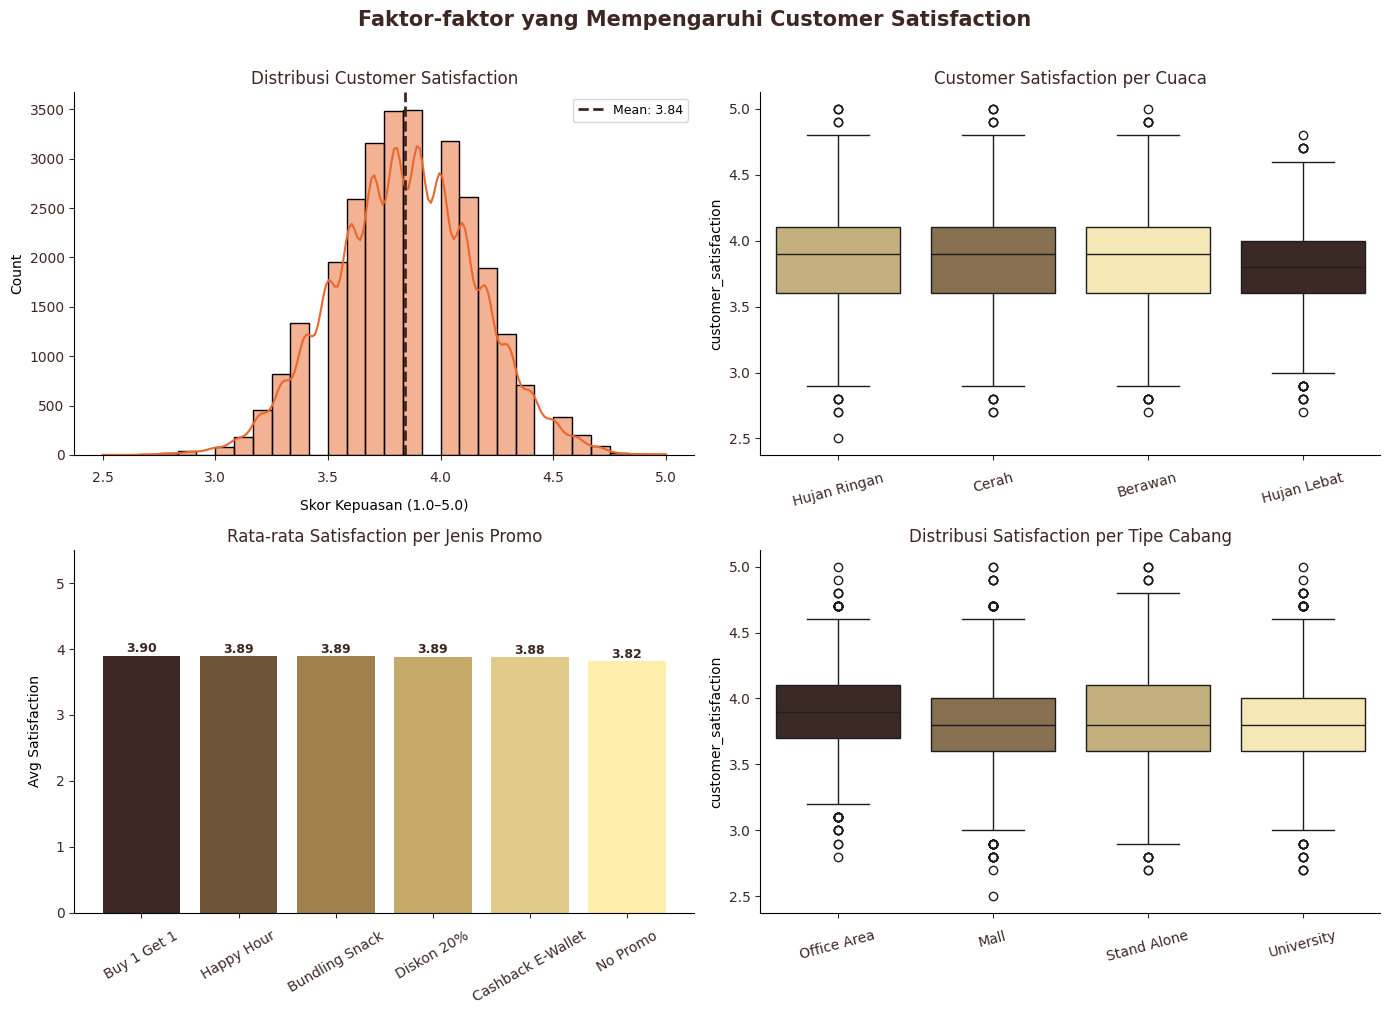


💡 INSIGHT: Identifikasi promo type & kondisi cuaca yang berkorelasi dengan skor kepuasan tertinggi.


In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')
for ax in axes.flat:
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(colors=KOPI_DARK)    # [DIUBAH: hardcode '#6F4E37' → KOPI_DARK]
    ax.title.set_color(KOPI_DARK)

# Plot 1: Histogram distribusi satisfaction
ax1 = axes[0][0]
sns.histplot(df['customer_satisfaction'], bins=30, kde=True,
             ax=ax1, color=KOPI_ORANGE)
ax1.axvline(df['customer_satisfaction'].mean(),
            color=KOPI_DARK, linestyle='--', linewidth=2,
            label=f"Mean: {df['customer_satisfaction'].mean():.2f}")
ax1.legend(fontsize=9)
ax1.set_title('Distribusi Customer Satisfaction')
ax1.set_xlabel('Skor Kepuasan (1.0–5.0)', labelpad=10)
ax1.tick_params(axis='x', pad=8)

# Plot 2: Boxplot per cuaca
ax2 = axes[0][1]
weather_order = sat_weather.index.tolist()
sns.boxplot(x='weather', y='customer_satisfaction', data=df,
            order=weather_order,
            palette=kopi_colors(len(weather_order), reverse=False),
            hue='weather', legend=False, ax=ax2)
ax2.set_title('Customer Satisfaction per Cuaca')
ax2.set_xlabel('', labelpad=10)
ax2.tick_params(axis='x', rotation=15, pad=8)

# Plot 3: Bar per jenis promo
ax3 = axes[1][0]
sat_promo_type = df.groupby('promo_type')['customer_satisfaction'].mean().sort_values(ascending=False)
bars = ax3.bar(sat_promo_type.index, sat_promo_type.values,
               color=kopi_colors(len(sat_promo_type), reverse=True))
ax3.set_title('Rata-rata Satisfaction per Jenis Promo')
ax3.set_ylabel('Avg Satisfaction', labelpad=10)
ax3.set_ylim(0, 5.5)
ax3.tick_params(axis='x', rotation=30, pad=8)
for bar in bars:
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=9,
             fontweight='bold', color=KOPI_DARK)

# Plot 4: Boxplot per tipe cabang
ax4 = axes[1][1]
sns.boxplot(x='branch_type', y='customer_satisfaction', data=df,
            palette=kopi_colors(df['branch_type'].nunique(), reverse=True),
            hue='branch_type', legend=False, ax=ax4)
ax4.set_title('Distribusi Satisfaction per Tipe Cabang')
ax4.set_xlabel('', labelpad=10)
ax4.tick_params(axis='x', rotation=15, pad=8)

fig.suptitle('Faktor-faktor yang Mempengaruhi Customer Satisfaction',
             fontsize=15, fontweight='bold', color=KOPI_DARK, y=1.01)
plt.tight_layout()
plt.show()
print('\n💡 INSIGHT: Identifikasi promo type & kondisi cuaca yang berkorelasi dengan skor kepuasan tertinggi.')


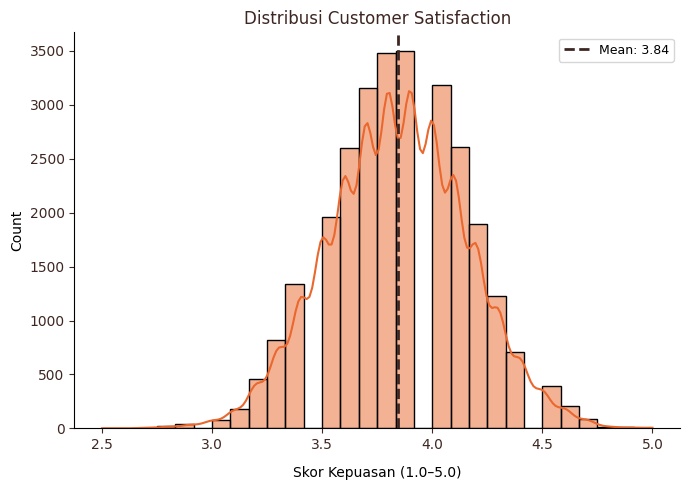

In [46]:
fig, ax1 = plt.subplots(figsize=(7, 5), facecolor='white')

ax1.set_facecolor('white')
ax1.spines[['top','right']].set_visible(False)
ax1.tick_params(colors=KOPI_DARK)
ax1.title.set_color(KOPI_DARK)

sns.histplot(df['customer_satisfaction'], bins=30, kde=True,
             ax=ax1, color=KOPI_ORANGE)

ax1.axvline(df['customer_satisfaction'].mean(),
            color=KOPI_DARK, linestyle='--', linewidth=2,
            label=f"Mean: {df['customer_satisfaction'].mean():.2f}")

ax1.legend(fontsize=9)
ax1.set_title('Distribusi Customer Satisfaction')
ax1.set_xlabel('Skor Kepuasan (1.0–5.0)', labelpad=10)

plt.tight_layout()
plt.show()

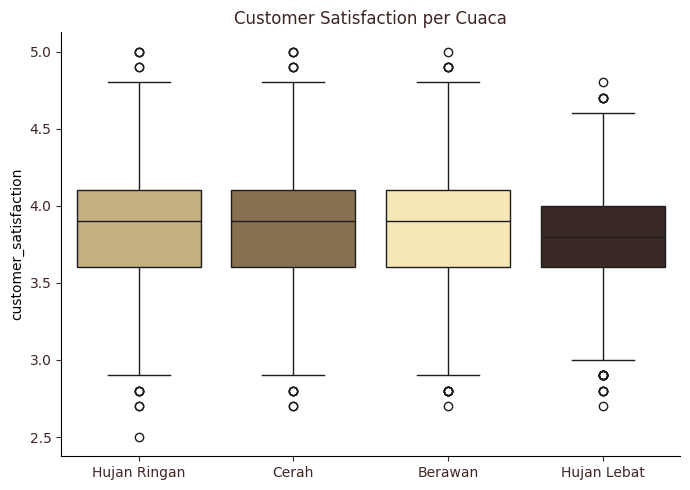

In [47]:
fig, ax2 = plt.subplots(figsize=(7, 5), facecolor='white')

ax2.set_facecolor('white')
ax2.spines[['top','right']].set_visible(False)
ax2.tick_params(colors=KOPI_DARK)
ax2.title.set_color(KOPI_DARK)

weather_order = sat_weather.index.tolist()

sns.boxplot(x='weather', y='customer_satisfaction', data=df,
            order=weather_order,
            palette=kopi_colors(len(weather_order), reverse=False),
            hue='weather', legend=False, ax=ax2)

ax2.set_title('Customer Satisfaction per Cuaca')
ax2.set_xlabel('')

plt.tight_layout()
plt.show()

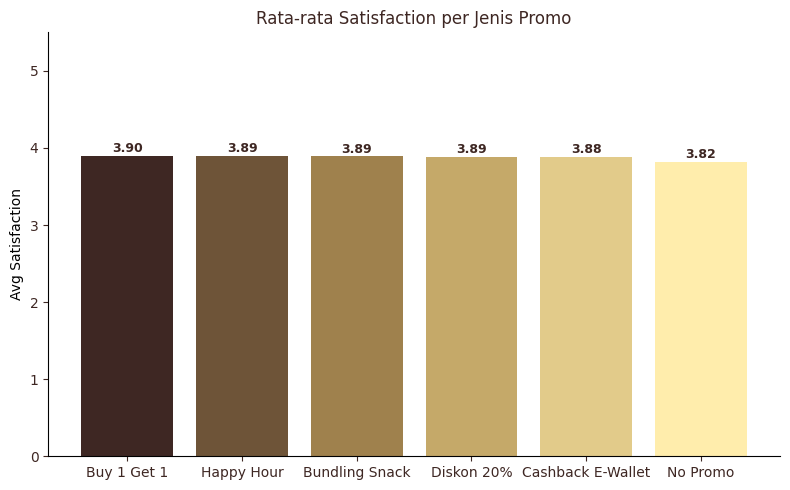

In [48]:
fig, ax3 = plt.subplots(figsize=(8, 5), facecolor='white')

ax3.set_facecolor('white')
ax3.spines[['top','right']].set_visible(False)
ax3.tick_params(colors=KOPI_DARK)
ax3.title.set_color(KOPI_DARK)

sat_promo_type = df.groupby('promo_type')['customer_satisfaction'].mean().sort_values(ascending=False)

bars = ax3.bar(sat_promo_type.index, sat_promo_type.values,
               color=kopi_colors(len(sat_promo_type), reverse=True))

ax3.set_title('Rata-rata Satisfaction per Jenis Promo')
ax3.set_ylabel('Avg Satisfaction')
ax3.set_ylim(0, 5.5)
ax3.tick_params(axis='x', rotation=0)

for bar in bars:
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=9,
             fontweight='bold', color=KOPI_DARK)

plt.tight_layout()
plt.show()

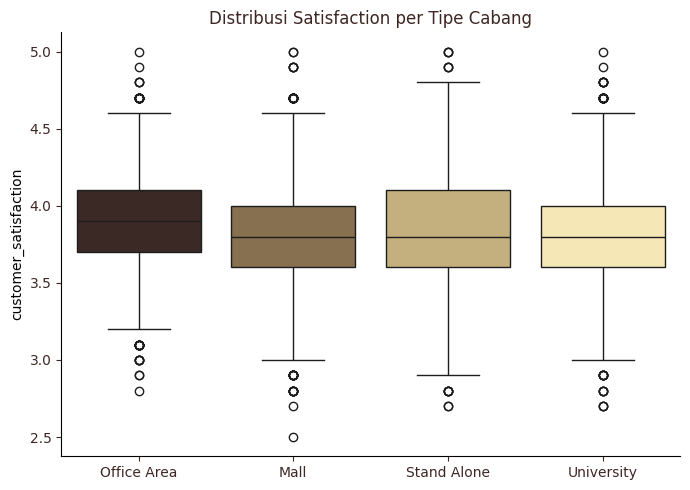

In [49]:
fig, ax4 = plt.subplots(figsize=(7, 5), facecolor='white')

ax4.set_facecolor('white')
ax4.spines[['top','right']].set_visible(False)
ax4.tick_params(colors=KOPI_DARK)
ax4.title.set_color(KOPI_DARK)

sns.boxplot(x='branch_type', y='customer_satisfaction', data=df,
            palette=kopi_colors(df['branch_type'].nunique(), reverse=True),
            hue='branch_type', legend=False, ax=ax4)

ax4.set_title('Distribusi Satisfaction per Tipe Cabang')
ax4.set_xlabel('')
ax4.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

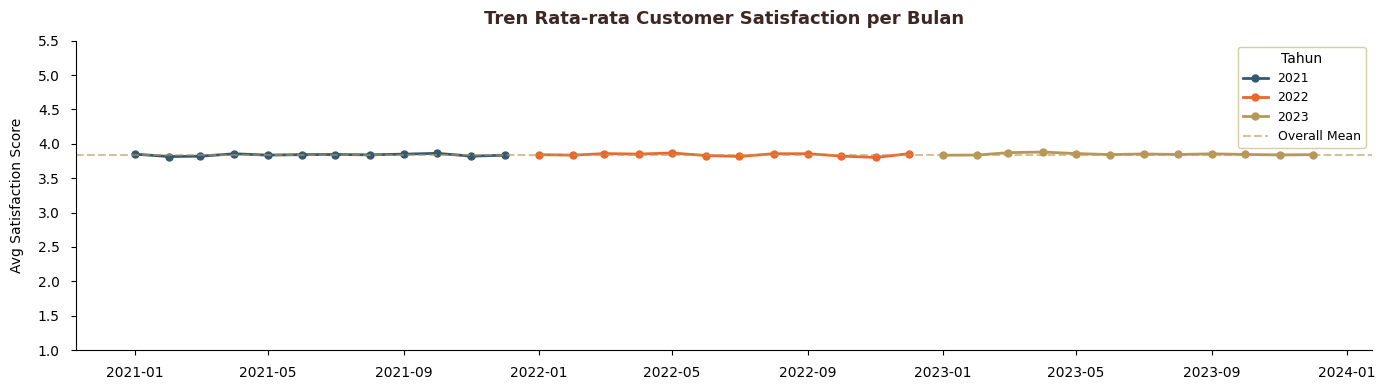

In [55]:
# Line chart tren satisfaction per bulan
sat_trend = df.groupby(['year','month'])['customer_satisfaction'].mean().reset_index()
sat_trend['period'] = pd.to_datetime(dict(year=sat_trend['year'], month=sat_trend['month'], day=1))

fig, ax = plt.subplots(figsize=(14, 4), facecolor='white')
ax.set_facecolor('white')
ax.spines[['top','right']].set_visible(False)

for yr, grp in sat_trend.groupby('year'):
    ax.plot(grp['period'], grp['customer_satisfaction'],
            marker='o', linewidth=2, markersize=5,
            color=KOPI_YEAR.get(yr, KOPI_MID), label=str(yr))

ax.axhline(df['customer_satisfaction'].mean(),
           color=KOPI_MID, linestyle='--', alpha=0.6, label='Overall Mean')
ax.set_title('Tren Rata-rata Customer Satisfaction per Bulan',
             fontsize=13, fontweight='bold', color=KOPI_DARK, pad=12)
ax.set_ylabel('Avg Satisfaction Score', labelpad=10)
ax.set_ylim(1, 5.5)
ax.legend(title='Tahun', fontsize=9, title_fontsize=10,
          framealpha=0.5, edgecolor=KOPI_MID)
ax.tick_params(axis='x', pad=8)
ax.tick_params(axis='y', pad=8)
plt.tight_layout()
plt.show()


---
## Bonus: Tren Revenue 2021–2023
> Pertanyaan pembuka: bagaimana revenue KopiSeru berkembang dari 2021 hingga 2023?

Revenue total per tahun:
  2021: Rp 22.53 M
  2022: Rp 39.14 M
  2023: Rp 58.40 M

YoY 2021→2022 : +73.7%
YoY 2022→2023 : +49.2%


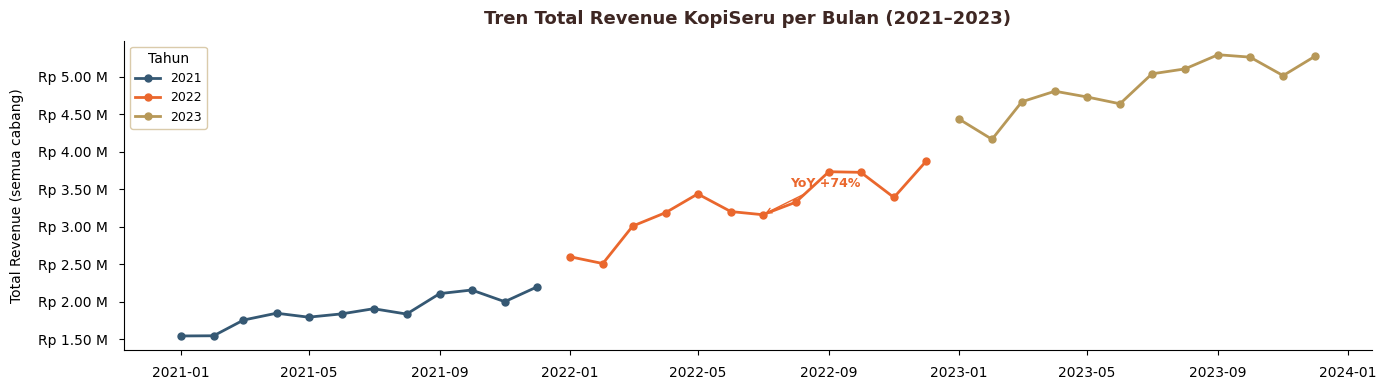


💡 INSIGHT: Revenue tumbuh signifikan YoY — pertumbuhan 2021→2022 lebih agresif, perlu dievaluasi apakah faktor pembukaan cabang baru atau kenaikan organik.

MoM Growth % (5 baris pertama & max/min):
    period  total_revenue  growth_%
2021-02-01   1546437000.0  0.170228
2021-03-01   1755896000.0 13.544619
2021-04-01   1846965000.0  5.186469
2021-05-01   1794146000.0 -2.859773
2021-06-01   1837971000.0  2.442666
  Max growth : +19.9% (Mar 2022)
  Min growth : -9.0% (Nov 2022)
💡 MoM growth memperlihatkan momentum — bulan berapa yang paling volatile?


In [54]:
# Tren revenue bulanan (sum semua cabang)
rev_trend = df.groupby(['year','month'])['total_revenue'].sum().reset_index()
rev_trend['period'] = pd.to_datetime(dict(year=rev_trend['year'], month=rev_trend['month'], day=1))

# YoY summary
rev_year = df.groupby('year')['total_revenue'].sum()
yoy_2122 = (rev_year[2022] - rev_year[2021]) / rev_year[2021] * 100
yoy_2223 = (rev_year[2023] - rev_year[2022]) / rev_year[2022] * 100
print('Revenue total per tahun:')
for yr, val in rev_year.items():
    print(f'  {yr}: {fmt_rupiah(val)}')
print(f'\nYoY 2021→2022 : {yoy_2122:+.1f}%')
print(f'YoY 2022→2023 : {yoy_2223:+.1f}%')

fig, ax = plt.subplots(figsize=(14, 4), facecolor='white')
ax.set_facecolor('white')
ax.spines[['top','right']].set_visible(False)

for yr, grp in rev_trend.groupby('year'):
    ax.plot(grp['period'], grp['total_revenue'],
            marker='o', linewidth=2, markersize=5,
            color=KOPI_YEAR.get(yr, KOPI_MID), label=f'{yr}')

ax.set_title('Tren Total Revenue KopiSeru per Bulan (2021–2023)',
             fontsize=13, fontweight='bold', color=KOPI_DARK, pad=12)
ax.set_ylabel('Total Revenue (semua cabang)', labelpad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))   # otomatis JT / Miliar
ax.legend(title='Tahun', fontsize=9, title_fontsize=10,
          framealpha=0.5, edgecolor=KOPI_MID)
ax.tick_params(axis='x', pad=8)
ax.tick_params(axis='y', pad=8)

# Anotasi YoY
ax.annotate(f'YoY +{yoy_2122:.0f}%', xy=(rev_trend[rev_trend['year']==2022]['period'].iloc[6],
             rev_trend[rev_trend['year']==2022]['total_revenue'].iloc[6]),
             xytext=(20, 20), textcoords='offset points',
             fontsize=9, color=KOPI_ORANGE, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=KOPI_ORANGE))

plt.tight_layout()
plt.show()
print('\n💡 INSIGHT: Revenue tumbuh signifikan YoY — pertumbuhan 2021→2022 lebih agresif, perlu dievaluasi apakah faktor pembukaan cabang baru atau kenaikan organik.')

# ── REVISI: MoM Growth % ──
rev_trend['growth_%'] = rev_trend['total_revenue'].pct_change() * 100
print('\nMoM Growth % (5 baris pertama & max/min):')
print(rev_trend[['period','total_revenue','growth_%']].dropna().head(5).to_string(index=False))
print(f'  Max growth : {rev_trend["growth_%"].max():+.1f}% '
      f'({rev_trend.loc[rev_trend["growth_%"].idxmax(), "period"].strftime("%b %Y")})')
print(f'  Min growth : {rev_trend["growth_%"].min():+.1f}% '
      f'({rev_trend.loc[rev_trend["growth_%"].idxmin(), "period"].strftime("%b %Y")})')
print('💡 MoM growth memperlihatkan momentum — bulan berapa yang paling volatile?')


---
## Export Dataset Bersih

In [52]:
# df.to_csv('kopiseru_clean.csv', index=False)
# print(f'Dataset bersih disimpan: kopiseru_clean.csv ({len(df):,} baris, {df.shape[1]} kolom)')


---
## Ringkasan Insight

| # | Pertanyaan | Temuan Awal |
|---|---|---|
| 1 | Promo → revenue? | Lihat output sel Analisis 1 |
| 2 | Cabang paling profitable? | Lihat output sel Analisis 2 |
| 2a | Wilayah ekspansi? | Lihat sel Skor Ekspansi Wilayah |
| 3 | Transaksi ↑ = revenue ↑? | Lihat korelasi & scatter Analisis 3 |
| 4 | Weekend effect? | Lihat bar chart Analisis 4 |
| 5 | Channel dominan? | Lihat pie & stacked bar Analisis 5 |
| 5a | Channel ekspansi? | Lihat sel Tren & Insight Channel |
| 6 | Faktor satisfaction? | Lihat heatmap & boxplot Analisis 6 |
| Bonus | Revenue trend 2021–2023 | Lihat line chart Bonus |

> **Catatan:** Angka konkret akan muncul setelah notebook dijalankan dengan data aktual.